In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_boxplots(df_list, labels, value_column='test_auc', separation=None, split = None,
                  horizontals=[], trace_line=False, title = "Boxplot comparison of different experiments", X_axis=None, Y_axis=None, 
                  TEXT_COLOR='white', BOX_COLOR='#E0E0E0', BACKGROUND_COLOR = "#1F1F1F"
                  ):
    """
    Plots boxplots of `value_column` across DataFrames (one box per DataFrame),
    grouped by `separation` (hue). If trace_line=True it traces a line through
    the medians for each separation category — aligned to the categorical x positions.

    New args:
    - X_axis: if not None, sets the x-axis label to this value
    - Y_axis: if not None, sets the y-axis label to this value
    """
    if split != None:
        # This recursive part assumes a function df_list_f exists in your scope
        try:
            for i, df in enumerate(df_list):
                df_list2, labels2 = df_list_f(df=df, split_by = split)
                plot_boxplots(df_list = df_list2, labels = labels2, value_column=value_column, separation=separation, split = None,
                      horizontals=horizontals, trace_line=trace_line, title = title + "  " + labels[i] , X_axis=X_axis, Y_axis=Y_axis,
                      TEXT_COLOR=TEXT_COLOR, BOX_COLOR=BOX_COLOR, BACKGROUND_COLOR=BACKGROUND_COLOR)
        except NameError as e:
            print("Error: The 'split' feature requires a function named 'df_list_f' to be defined.")
            print(e)
            return
    else:
        
        print(f'Background_color: {BACKGROUND_COLOR}')
        # Define the style dictionary for the dark background and white text
        style_dict = {
            "axes.facecolor": BACKGROUND_COLOR,    # Dark background
            "figure.facecolor":BACKGROUND_COLOR,   # Dark background
            "text.color": TEXT_COLOR,         # Default text
            "axes.labelcolor": TEXT_COLOR,    # Axis labels
            "axes.titlecolor": TEXT_COLOR,    # Title
            "xtick.color": TEXT_COLOR,        # X-axis tick labels
            "ytick.color": TEXT_COLOR,        # Y-axis tick labels
            "grid.color": TEXT_COLOR,          # Lighter grid for contrast
            "axes.edgecolor": TEXT_COLOR      # Plot border/spines
        }
        
        # --- Define props for ALL boxplot elements ---
        # These will be passed to sns.boxplot to make all lines white
        plot_props = {
            "boxprops": dict(edgecolor=BOX_COLOR),
            "whiskerprops": dict(color=BOX_COLOR),
            "capprops": dict(color=BOX_COLOR),
            "medianprops": dict(color=BOX_COLOR, linewidth=1), # Make median slightly thicker
            "flierprops": dict(markerfacecolor=BOX_COLOR, 
                               markeredgecolor=BOX_COLOR, 
                               marker='.') # Use a small dot for outliers
        }

        # Use 'with' to apply the style temporarily
        with sns.axes_style("darkgrid", style_dict):

            combined = []
            medians = []

            # --- 1. Data Preparation ---
            for i, df in enumerate(df_list):
                temp = df.copy()
                temp['DataFrame'] = labels[i]
                combined.append(temp)

                if separation is None:
                    medians.append((labels[i], temp[value_column].median()))
                else:
                    for sep_val in temp[separation].unique():
                        m = temp.loc[temp[separation] == sep_val, value_column].median()
                        medians.append((labels[i], sep_val, m))

            if separation is None:
                medians_df = pd.DataFrame(medians, columns=['DataFrame', 'Median'])
            else:
                medians_df = pd.DataFrame(medians, columns=['DataFrame', separation, 'Median'])

            all_data = pd.concat(combined, ignore_index=True)

            plt.figure(figsize=(12, 6))

            # --- 2. Plotting the Boxplot ---
            if separation is None:
                ax = sns.boxplot(
                    data=all_data,
                    x='DataFrame',
                    y=value_column,
                    hue = 'DataFrame',
                    legend = False,
                    palette='Set2',
                    order=labels,
                    **plot_props # Unpack all the white-line props
                )
                if ax.get_legend() is not None:
                    ax.get_legend().remove()
            else:
                ax = sns.boxplot(
                    data=all_data,
                    x='DataFrame',
                    y=value_column,
                    hue=separation,
                    palette='Set2',
                    order=labels,
                    **plot_props # Unpack all the white-line props
                )

                # --- 3. Plotting the Trace Line (if requested) ---
                if trace_line:
                    x = np.arange(len(labels))
                    
                    hue_levels = sorted(all_data[separation].unique())
                    palette = sns.color_palette("Set2", n_colors=len(hue_levels))
                    color_map = dict(zip(hue_levels, palette))

                    for i, sep_val in enumerate(hue_levels):
                        medians_for_hue = medians_df[medians_df[separation] == sep_val]
                        
                        ordered_medians = pd.DataFrame({'DataFrame': labels})
                        ordered_medians = ordered_medians.merge(
                            medians_for_hue, 
                            on='DataFrame', 
                            how='left'
                        )
                        y = ordered_medians['Median'].values 

                        ax.plot(
                            x, y, 
                            marker='.',        
                            linestyle='--',    
                            color=color_map[sep_val], 
                            zorder=10,         
                            alpha=0.9
                        )

            # --- 4. Plot Finalization and Styling (All Text White) ---
            
            ax.set_title(title, color=TEXT_COLOR, fontsize=16, pad=20)

            x_label = X_axis if X_axis is not None else 'DataFrame'
            y_label = Y_axis if Y_axis is not None else value_column
            ax.set_xlabel(x_label, color=TEXT_COLOR, fontsize=12, labelpad=15)
            ax.set_ylabel(y_label, color=TEXT_COLOR, fontsize=12, labelpad=15)

            ax.tick_params(axis='x', colors=TEXT_COLOR, labelsize=10)
            ax.tick_params(axis='y', colors=TEXT_COLOR, labelsize=10)
            
            for spine in ax.spines.values():
                spine.set_edgecolor(TEXT_COLOR)

            for h_val in horizontals:
                ax.axhline(y=h_val, color=TEXT_COLOR, linestyle=':', linewidth=1, alpha=0.8)

            if separation is not None:
                legend = ax.get_legend()
                if legend:
                    title_obj = legend.get_title()
                    if title_obj:
                        title_obj.set_color(TEXT_COLOR)
                    
                    for text in legend.get_texts():
                        text.set_color(TEXT_COLOR)
                    
                    frame = legend.get_frame()
                    frame.set_facecolor(BACKGROUND_COLOR) 
                    frame.set_edgecolor(TEXT_COLOR)

        # --- 5. Show the Plot ---
        plt.tight_layout() 
        plt.show()

def df_list_f(df, split_by):
    
    df_list = []
    labels = []
    print(df[split_by].unique())
    for element in df[split_by].unique():
        df_list.append( df[ df[split_by] == element ] )
        labels.append(str(element))
    
    return df_list, labels

In [2]:
import pandas as pd
from benri.graphics import plot_boxplots

['Unprocessed' '[0]' '[1]' '[2]' '[3]']
Background_color: white


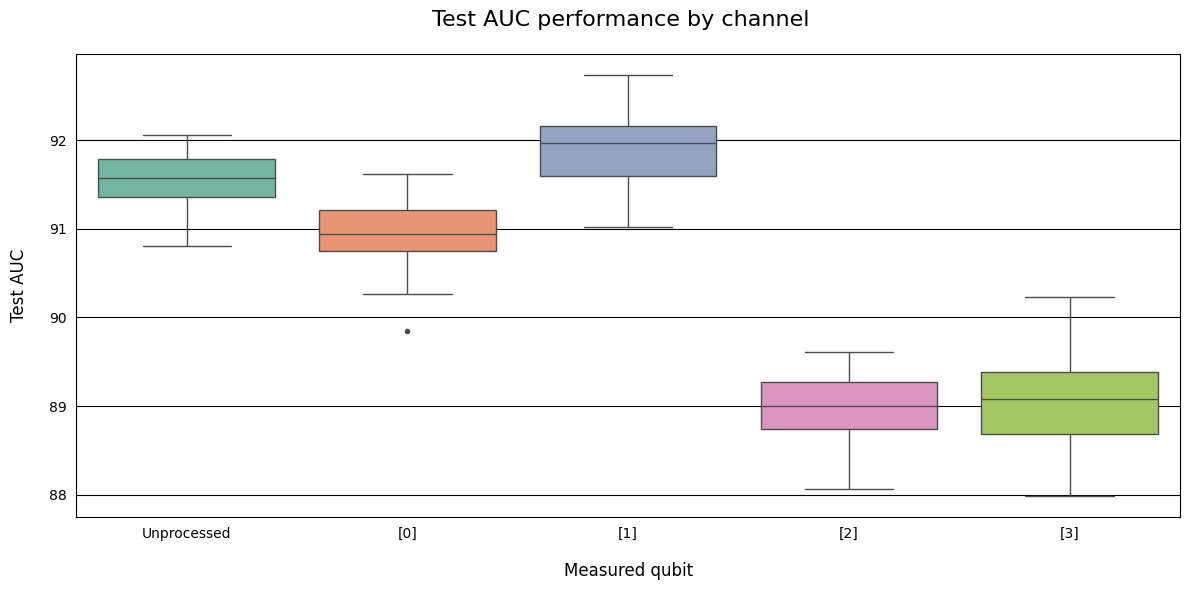

In [3]:
df = pd.read_csv("qdata/results_grid_search.csv")
df = df[ df['test_auc']>= 70 ]
mask = df['q_config'] == 'none'
df.loc[mask,'channels_out'] = 'Unprocessed'
plot_boxplots([df], [''], value_column='test_auc', separation= None, split = 'channels_out', TEXT_COLOR='black', BACKGROUND_COLOR='white', BOX_COLOR='#4c4c4cff', title = "Test AUC performance by channel",
X_axis= 'Measured qubit', Y_axis='Test AUC')

['quantum' 'none']
[False  True]
Background_color: #1F1F1F


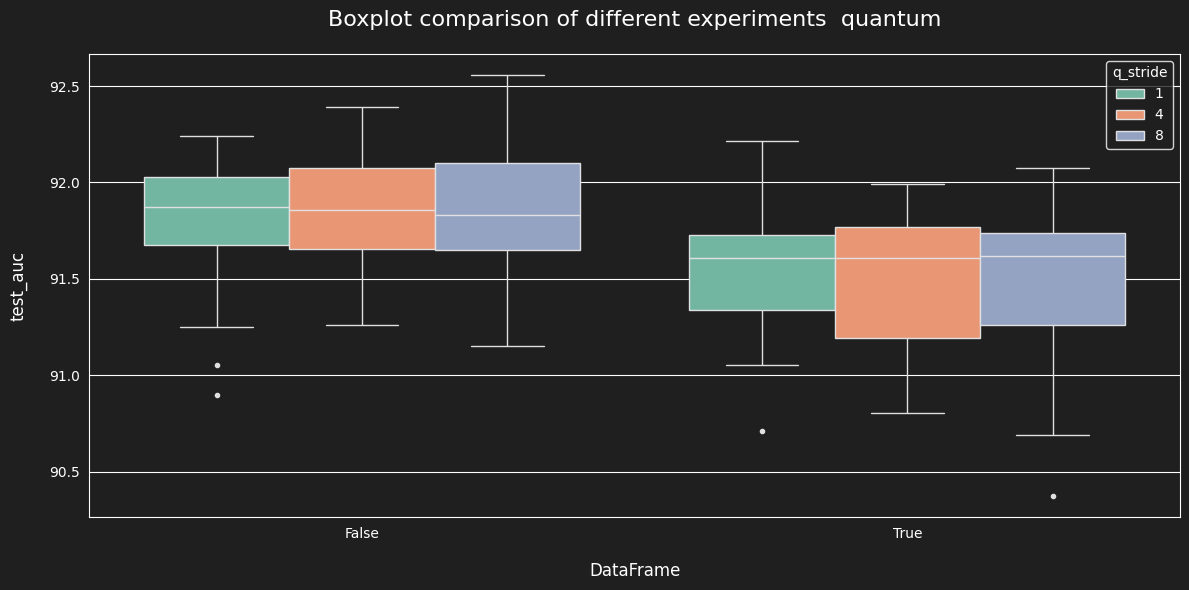

[False  True]
Background_color: #1F1F1F


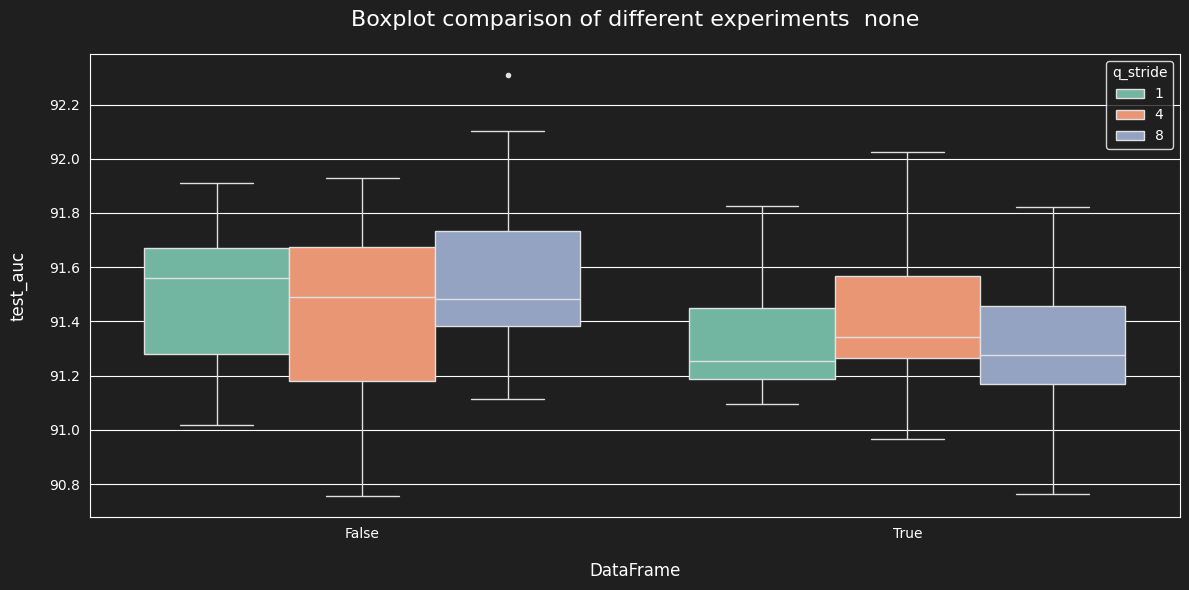

In [3]:
df_QCQC = pd.read_csv("QorC_QorC_q_stride/results_grid_search.csv")
df_list, labels =  df_list_f(df_QCQC, split_by="q_config")
plot_boxplots(df_list, labels, separation = "q_stride", split = "quantum")

[1 4 8]
Background_color: #ffffff00


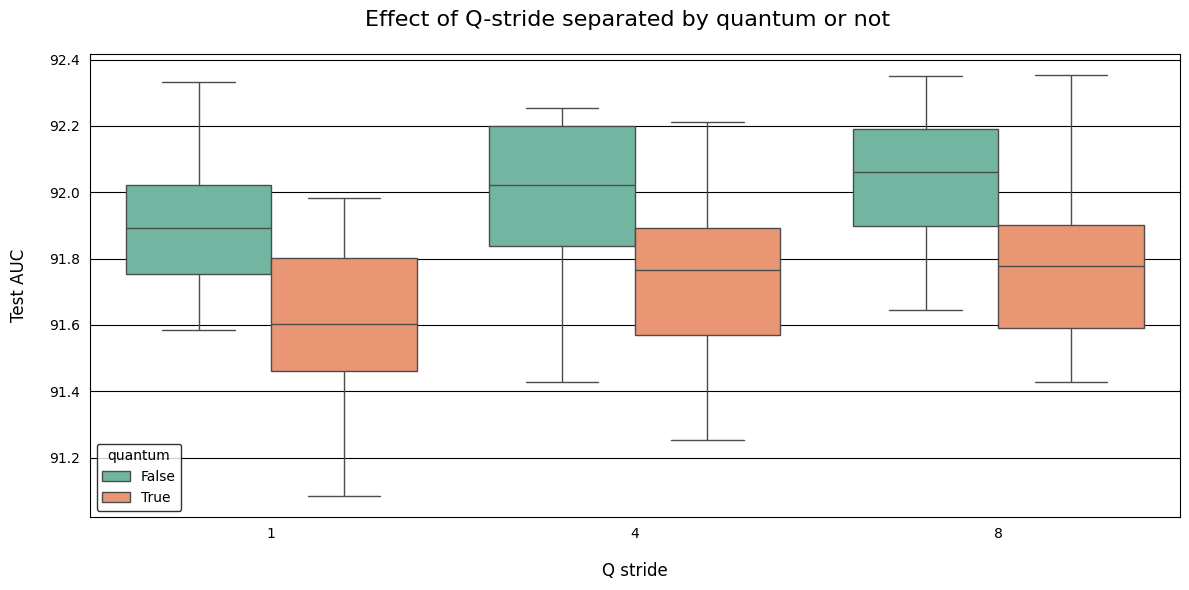

In [4]:
df_stride = pd.read_csv("q_stride_redo2/results_grid_search.csv")
plot_boxplots([df_stride], [""], split = "q_stride", separation = "quantum", TEXT_COLOR='black', BACKGROUND_COLOR='#ffffff00', BOX_COLOR='#4c4c4cff', title = "Effect of Q-stride separated by quantum or not",
X_axis= 'Q stride', Y_axis='Test AUC')

['CRX' 'edges']
['none' 'quantum']
Background_color: #ffffff00


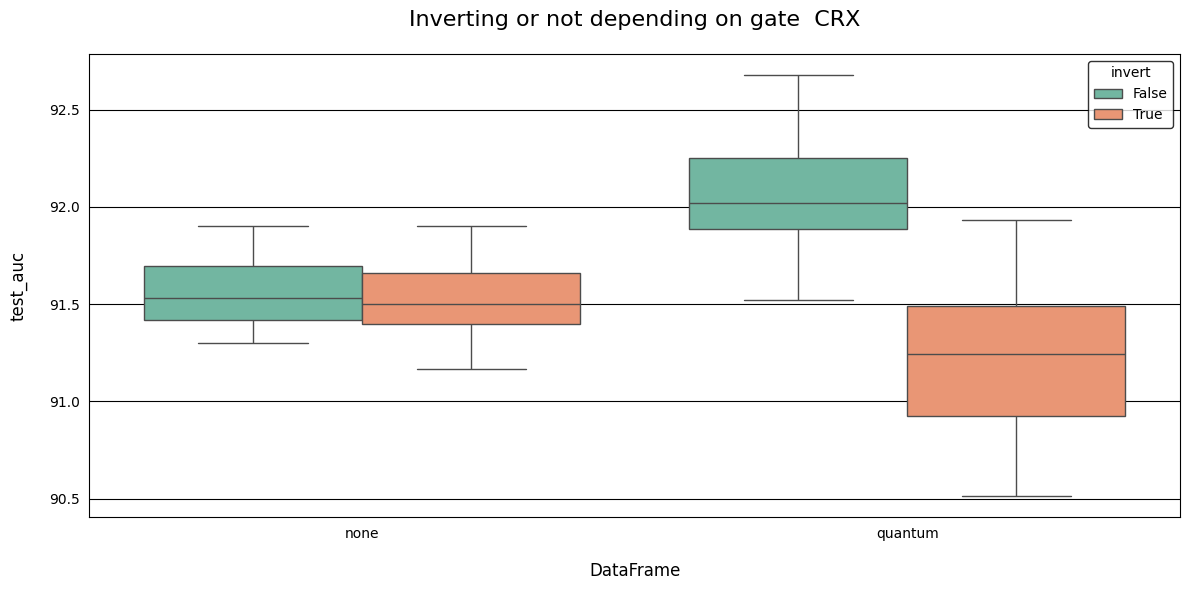

['none' 'quantum']
Background_color: #ffffff00


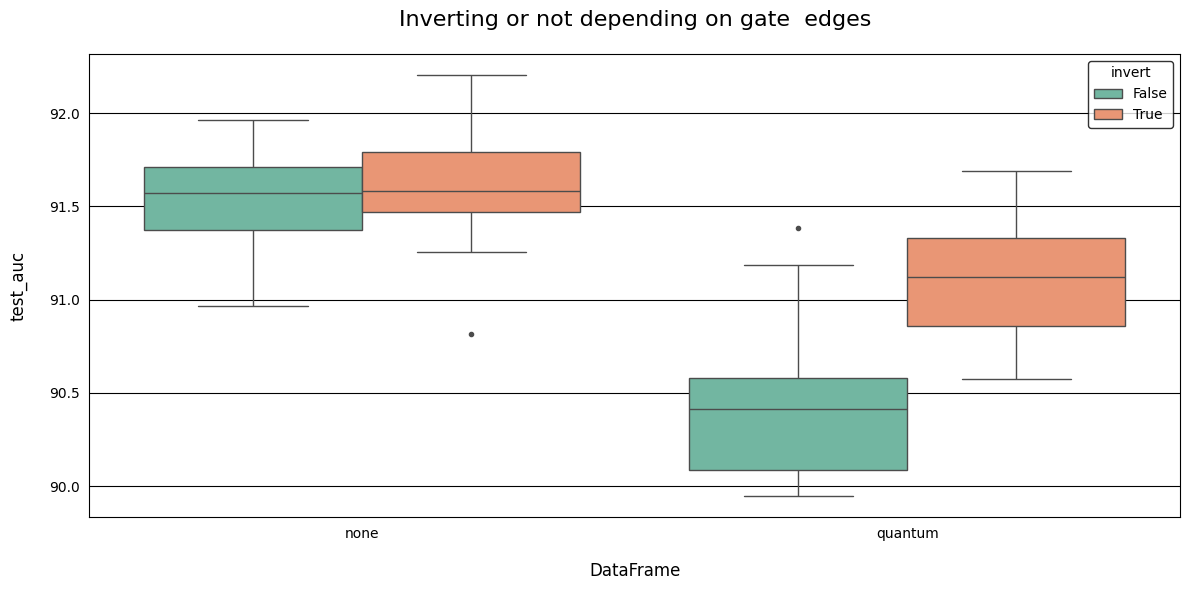

In [5]:
path = "quantum_cricuit_exploration/results_grid_search.csv"
df = pd.read_csv(path)
df_list, labels = df_list_f(df, split_by= "entangle_method")
plot_boxplots(df_list, labels, split = "q_config", separation = "invert", TEXT_COLOR='black', BACKGROUND_COLOR='#ffffff00', BOX_COLOR='#4c4c4cff', title = "Inverting or not depending on gate")

['CRX' 'edges']
['none' 'quantum']
Background_color: #ffffff00


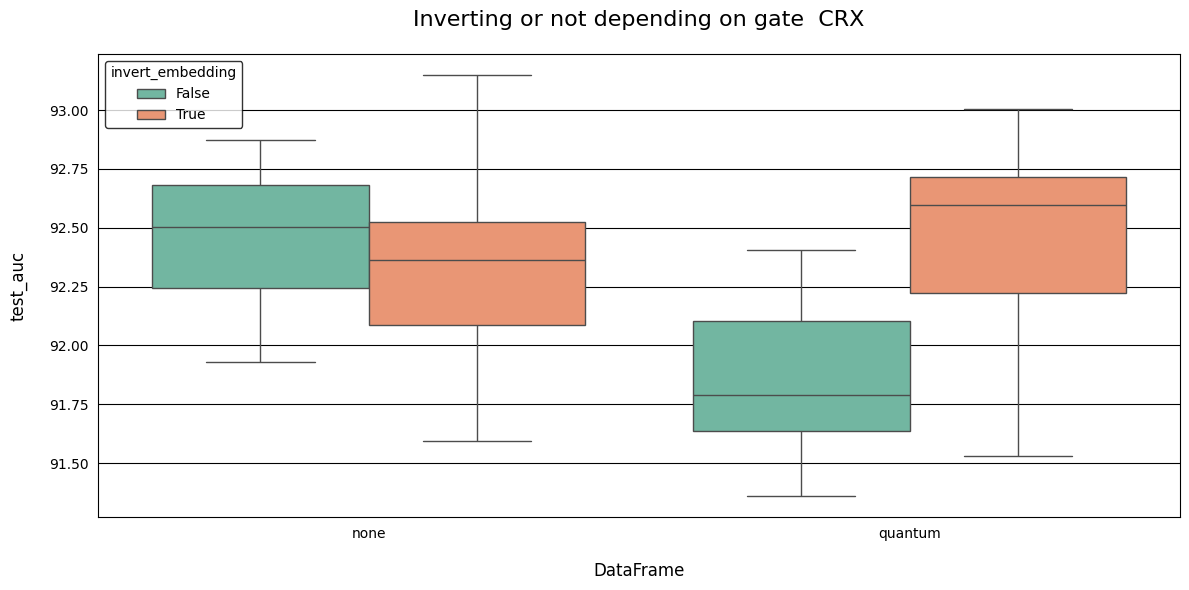

['none' 'quantum']
Background_color: #ffffff00


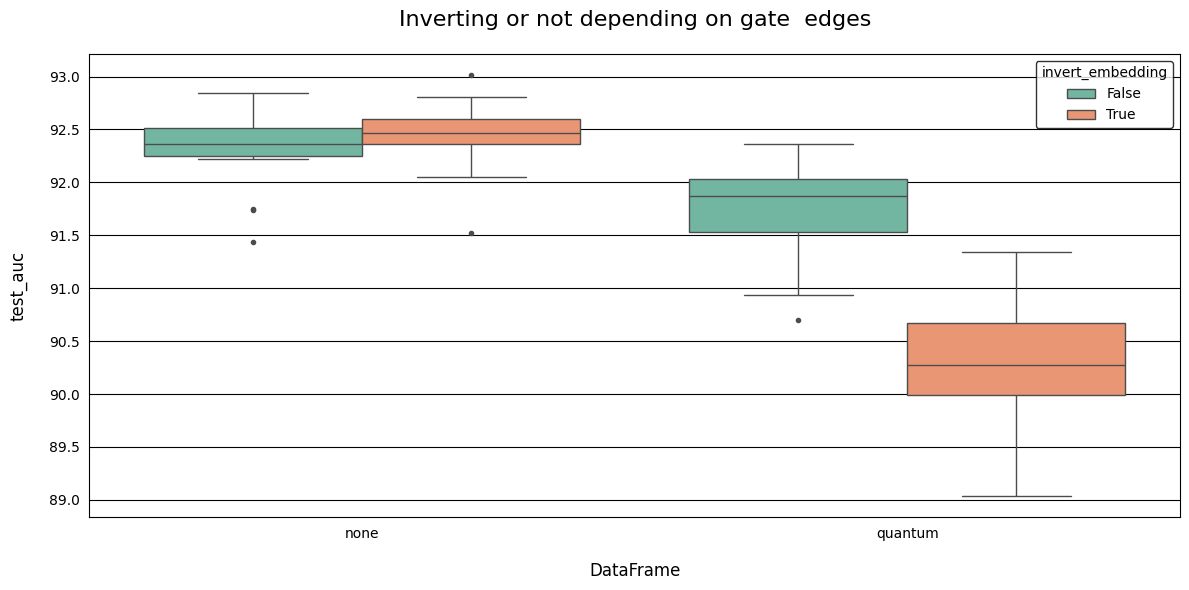

['none' 'quantum']
Background_color: #ffffff00


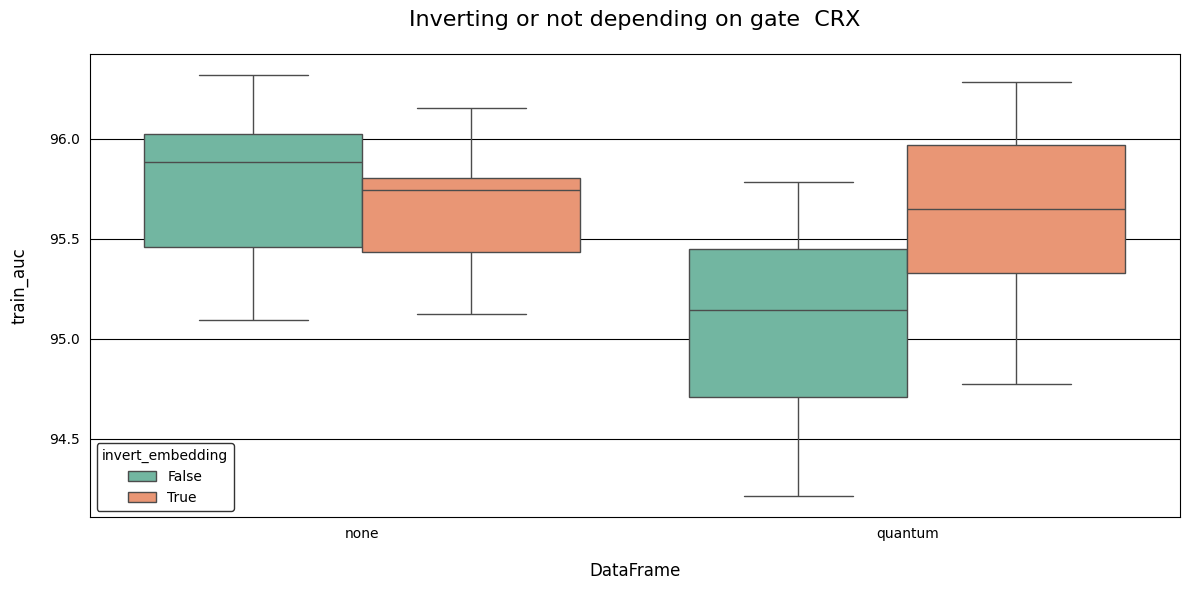

['none' 'quantum']
Background_color: #ffffff00


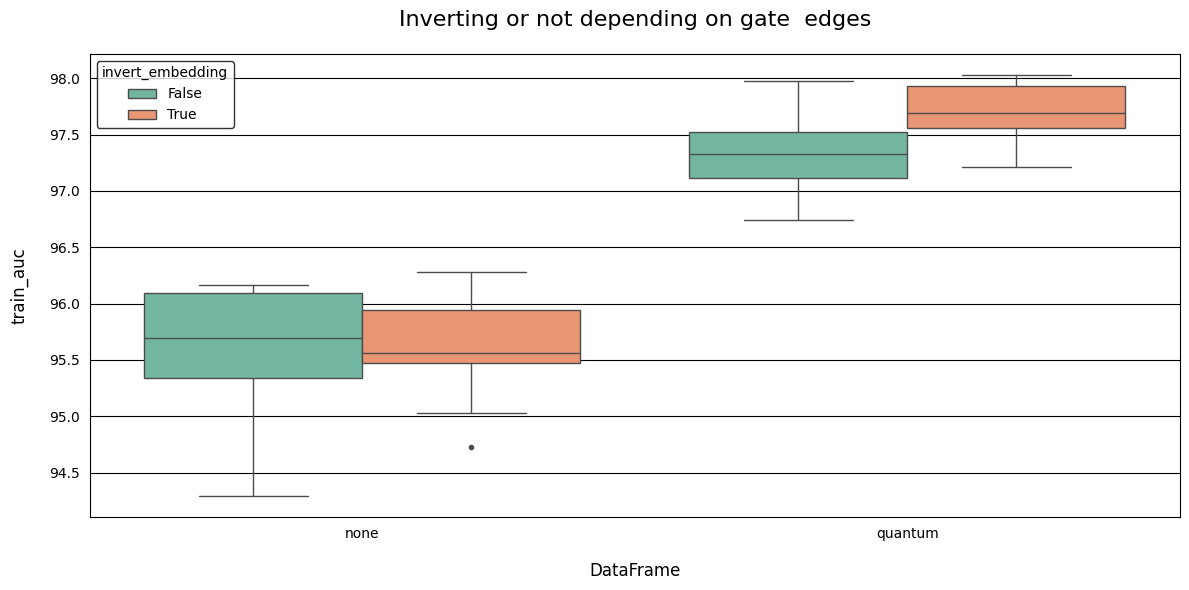

In [6]:
path = "64x64/CRX_v_Edges_invert_q_v_c/results_grid_search.csv"
df = pd.read_csv(path)
df_list, labels = df_list_f(df, split_by= "entangle_method")
plot_boxplots(df_list, labels, split = "q_config", separation = "invert_embedding", TEXT_COLOR='black', BACKGROUND_COLOR='#ffffff00', BOX_COLOR='#4c4c4cff', title = "Inverting or not depending on gate")
plot_boxplots(df_list, labels, split = "q_config", separation = "invert_embedding", value_column='train_auc', TEXT_COLOR='black', BACKGROUND_COLOR='#ffffff00', BOX_COLOR='#4c4c4cff', title = "Inverting or not depending on gate")

['none' 'quantum']
['CRX' 'edges']
[0.35 0.5 ]
Background_color: #ffffff00


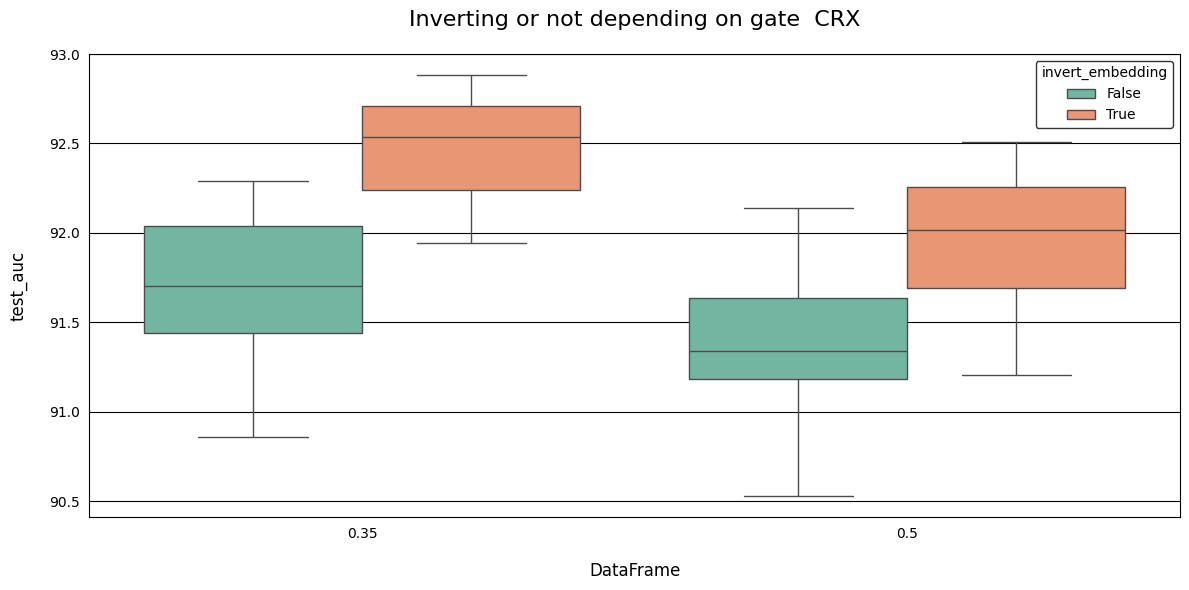

[0.35 0.5 ]
Background_color: #ffffff00


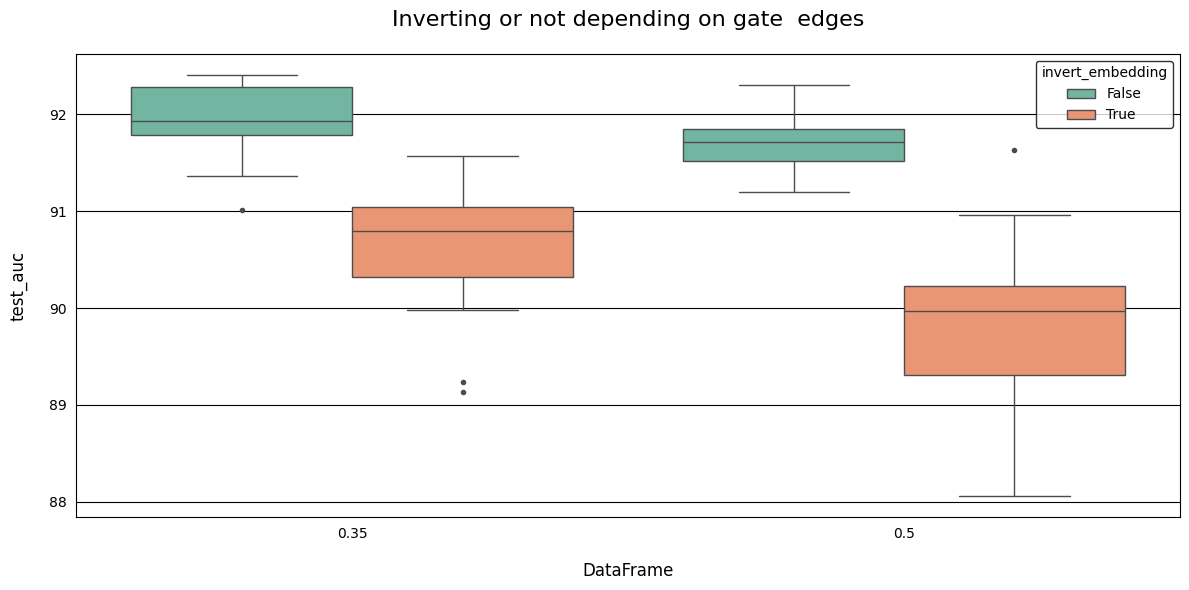

[0.35 0.5 ]
Background_color: #ffffff00


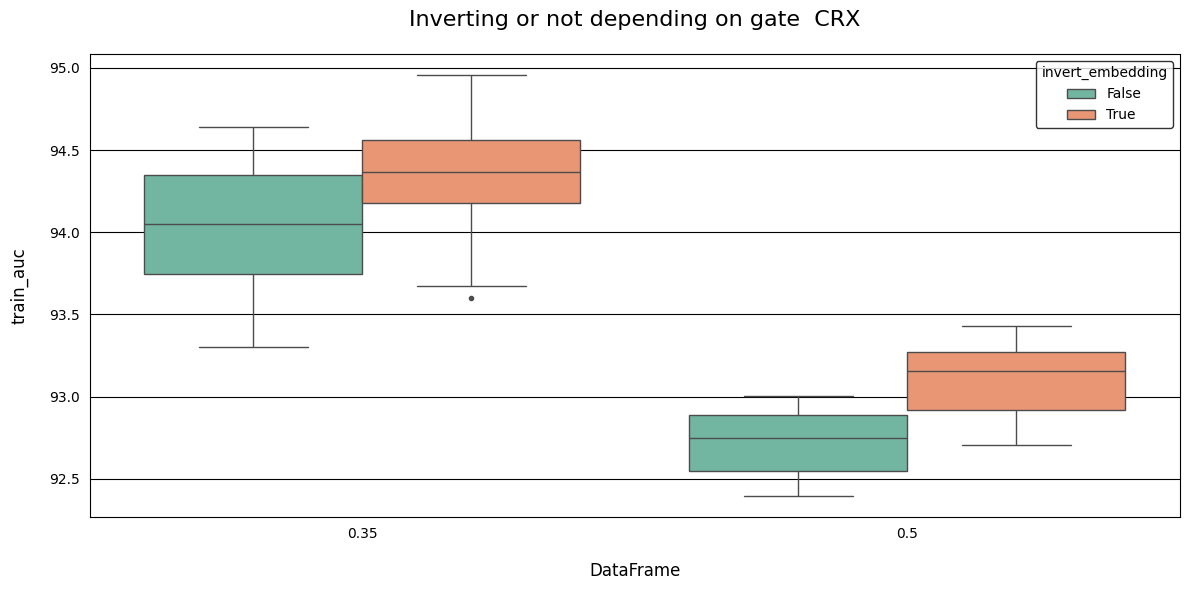

[0.35 0.5 ]
Background_color: #ffffff00


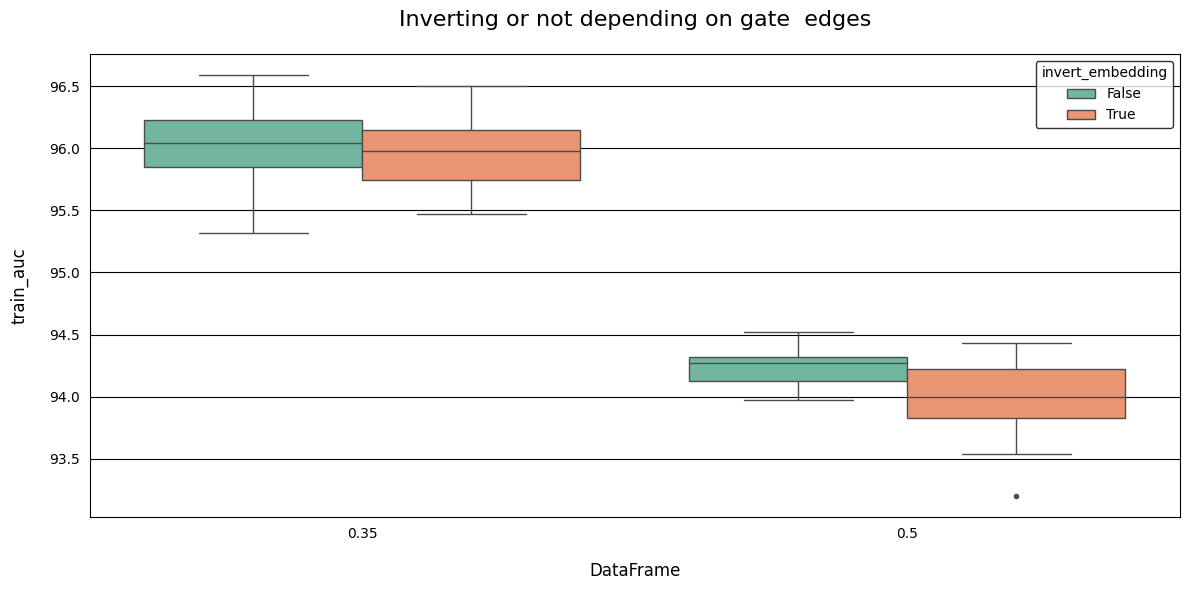

In [7]:
path = "64x64/CRX_v_Edges_invert_q_v_c_dropout/results_grid_search.csv"
df = pd.read_csv(path)
df_list, labels = df_list_f(df, split_by= "q_config")
quantumdf, qlabels =  df_list_f(df_list[1], split_by= "entangle_method")
plot_boxplots(quantumdf, qlabels, split = "dropout", separation = "invert_embedding", TEXT_COLOR='black', BACKGROUND_COLOR='#ffffff00', BOX_COLOR='#4c4c4cff', title = "Inverting or not depending on gate")
plot_boxplots(quantumdf, qlabels, split = "dropout", separation = "invert_embedding", value_column='train_auc', TEXT_COLOR='black', BACKGROUND_COLOR='#ffffff00', BOX_COLOR='#4c4c4cff', title = "Inverting or not depending on gate")

# QSTRIDE AND MLPSIZE AND DROPOut

[0.175 0.275 0.375]
[1 2 4 8]
Background_color: #ffffff00


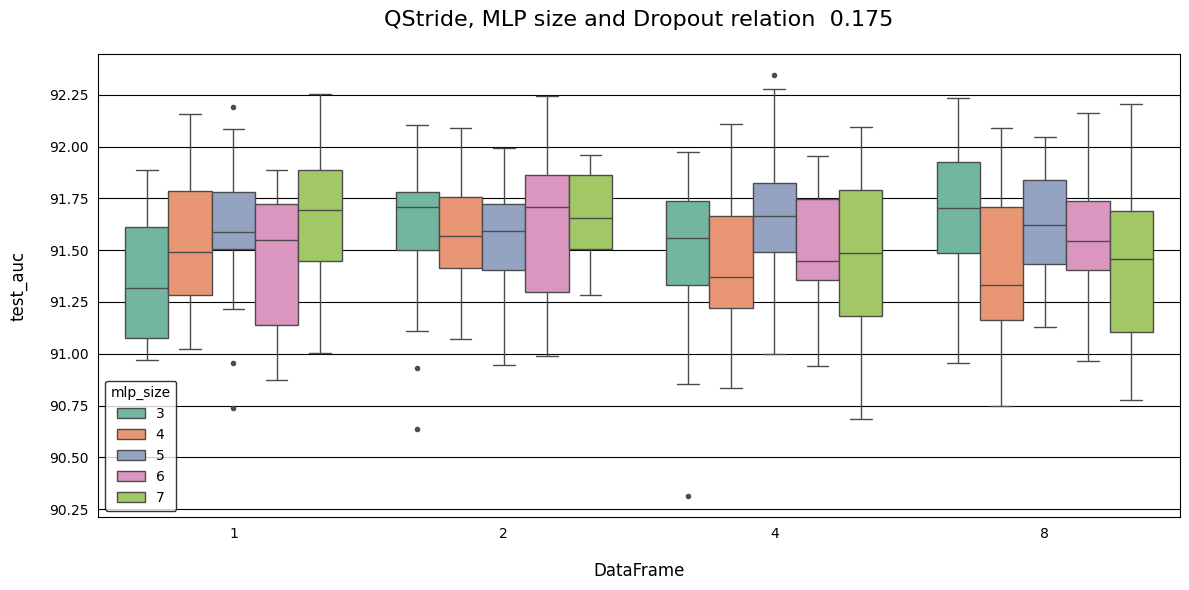

[1 2 4 8]
Background_color: #ffffff00


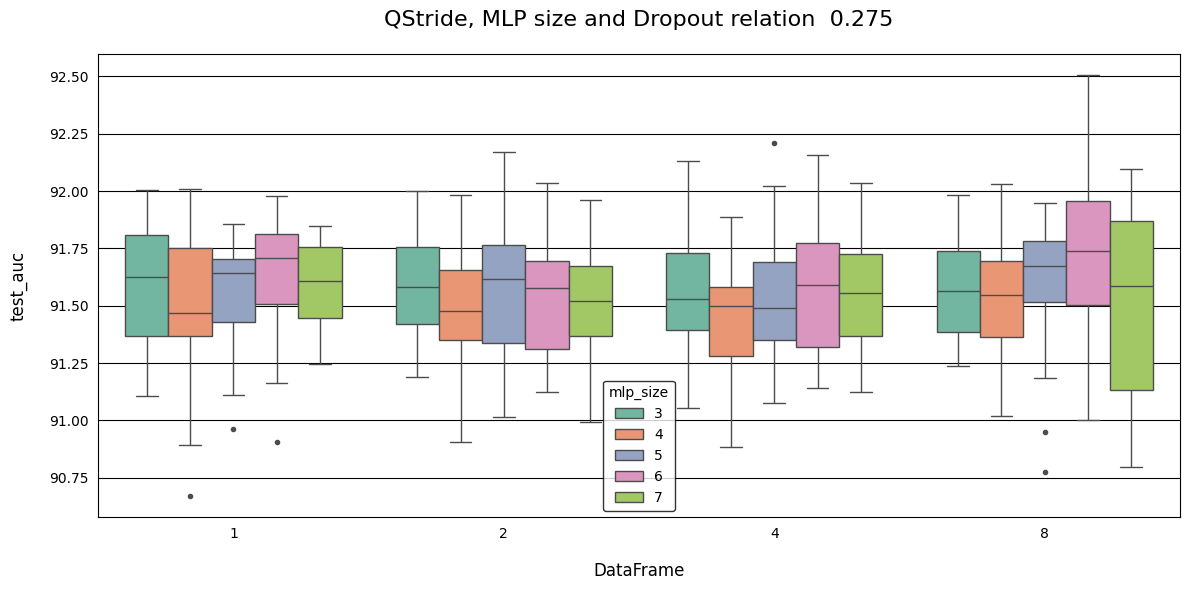

[1 2 4 8]
Background_color: #ffffff00


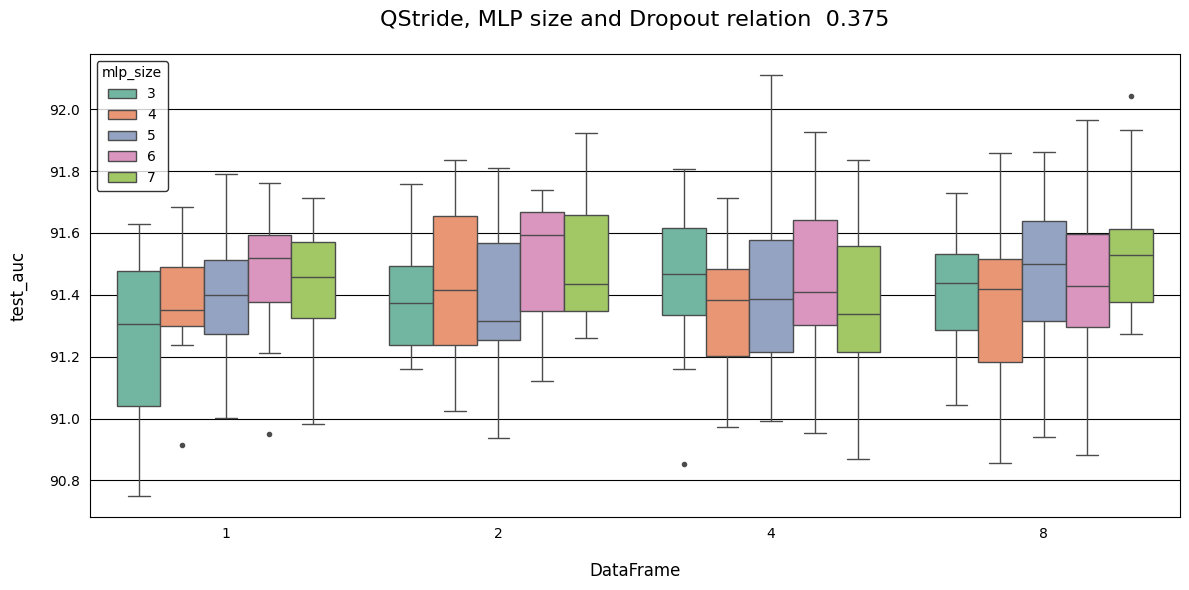

[1 2 4 8]
Background_color: #ffffff00


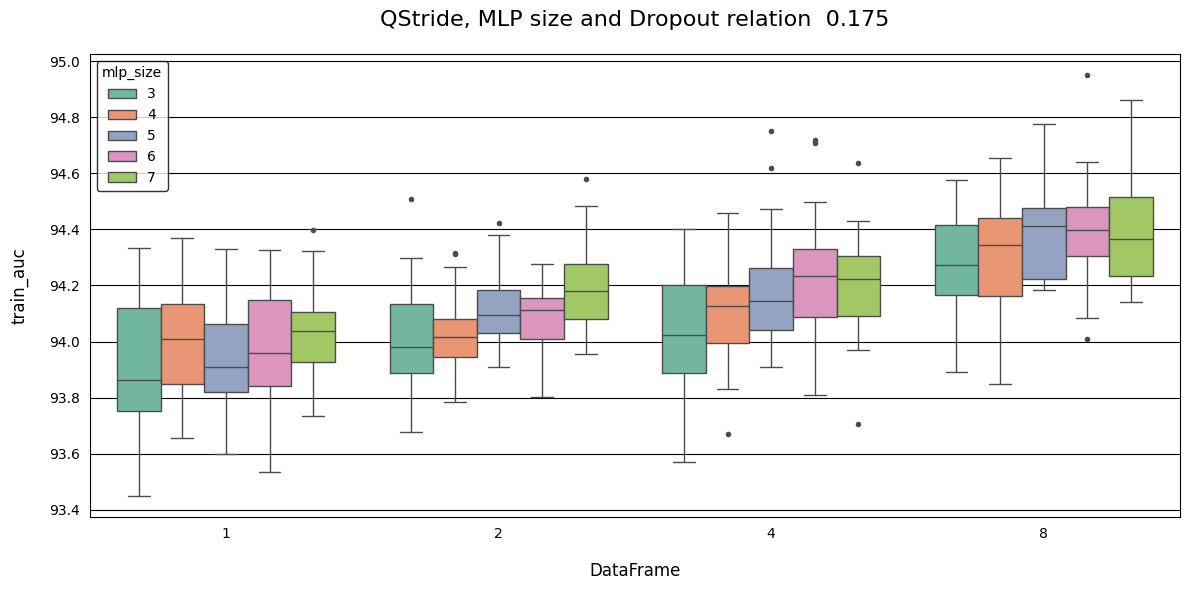

[1 2 4 8]
Background_color: #ffffff00


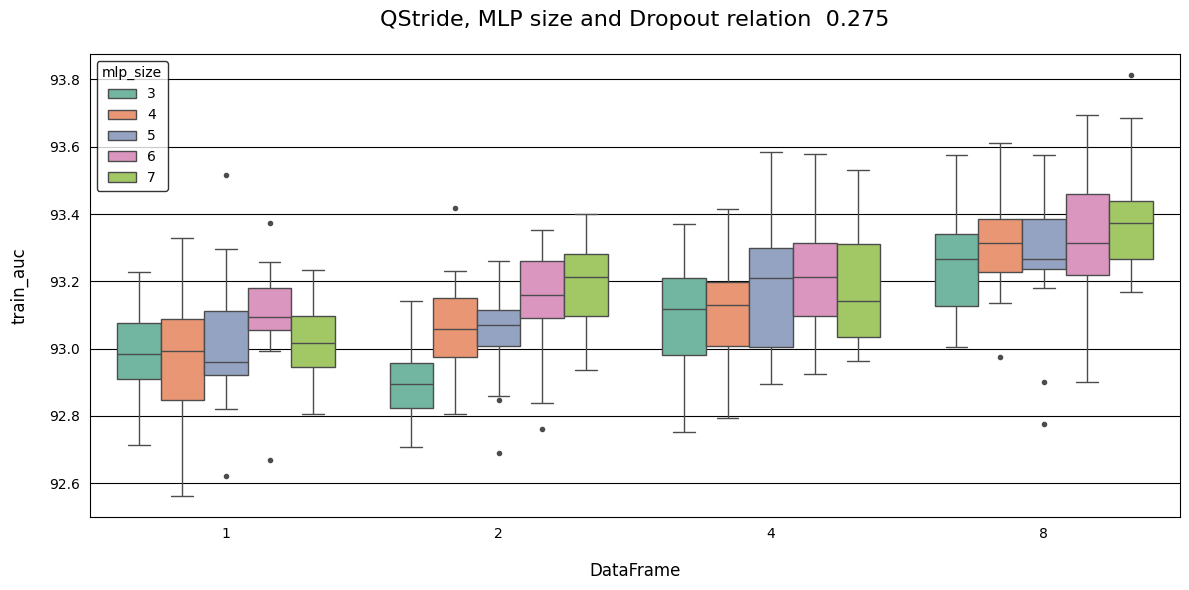

[1 2 4 8]
Background_color: #ffffff00


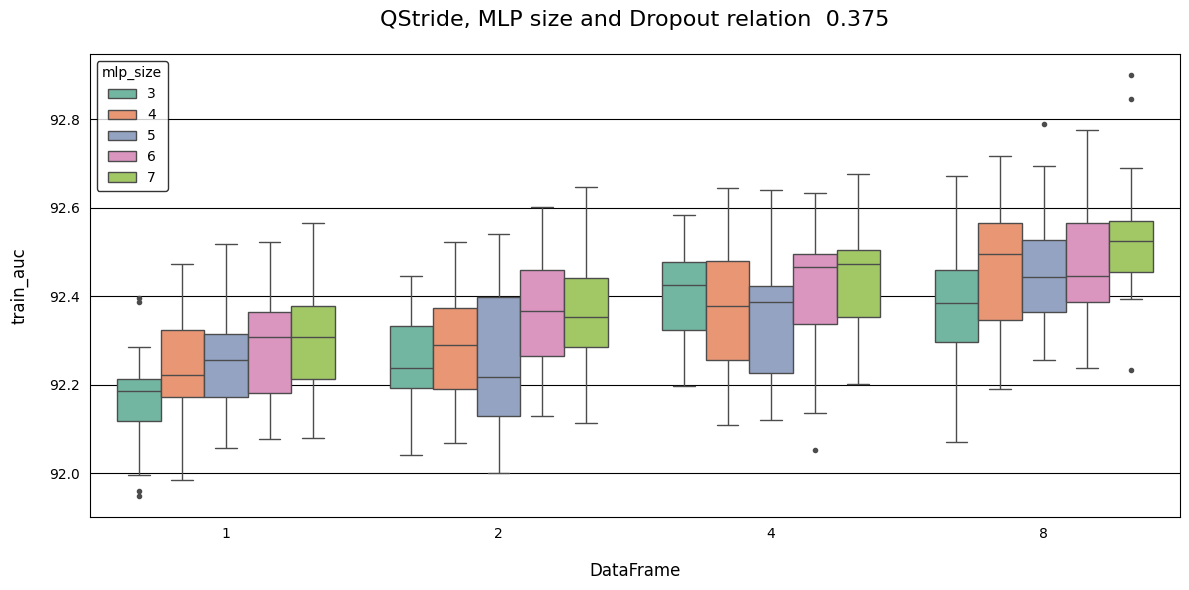

In [8]:
path = "q_stride_mlp_size_dropout_relation/results_grid_search.csv"
df = pd.read_csv(path)
df_list, labels = df_list_f(df, split_by= "dropout")
plot_boxplots(df_list, labels, split = "q_stride", separation = "mlp_size", TEXT_COLOR='black', BACKGROUND_COLOR='#ffffff00', BOX_COLOR='#4c4c4cff', title = "QStride, MLP size and Dropout relation")
plot_boxplots(df_list, labels, split = "q_stride", separation = "mlp_size", value_column='train_auc', TEXT_COLOR='black', BACKGROUND_COLOR='#ffffff00', BOX_COLOR='#4c4c4cff', title = "QStride, MLP size and Dropout relation")

['quantum' 'cosine' 'none' 'cosine2']
Background_color: #ffffff00


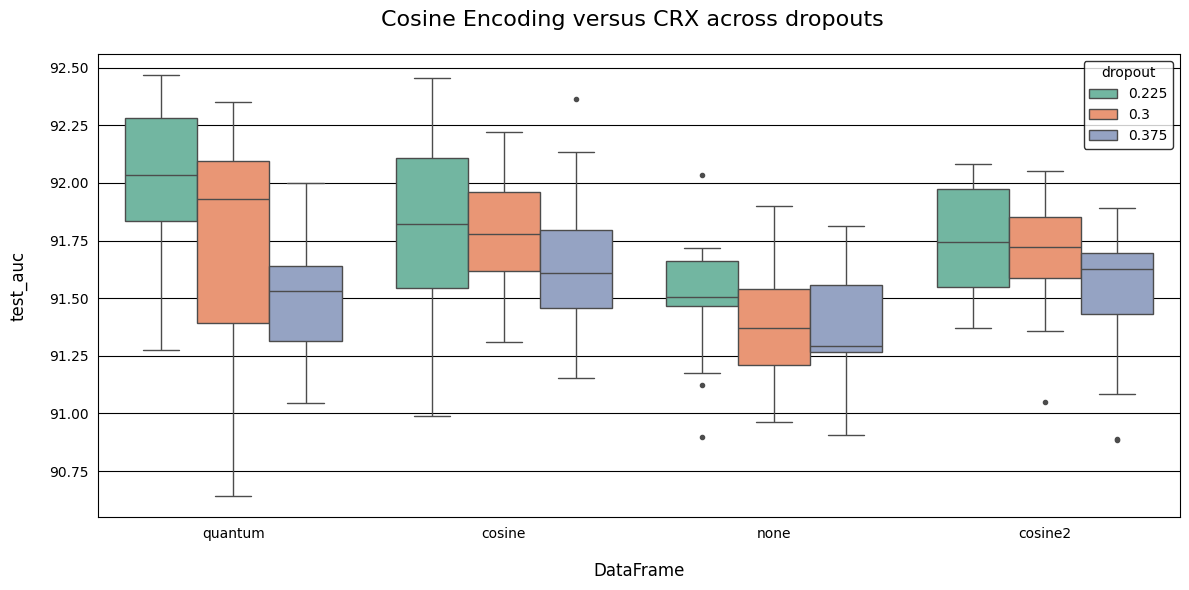

['quantum' 'cosine' 'none' 'cosine2']
Background_color: #ffffff00


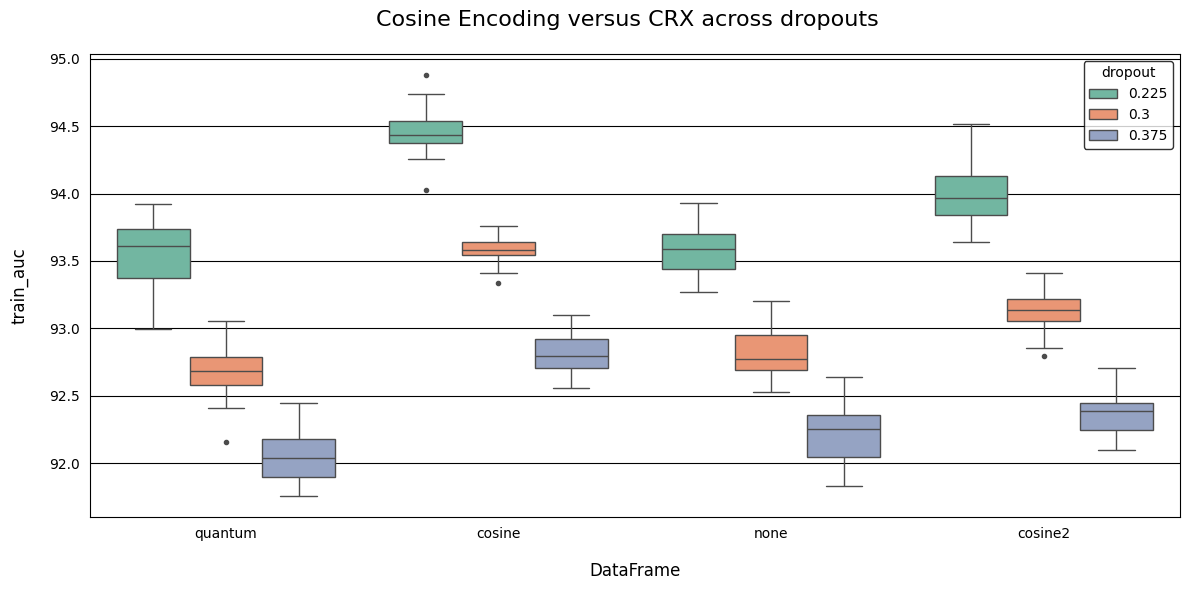

In [9]:
path = "crx_vs_cosine/results_grid_search.csv"
df = pd.read_csv(path)

plot_boxplots([df], [""], split = "q_config", separation = "dropout", TEXT_COLOR='black', BACKGROUND_COLOR='#ffffff00', BOX_COLOR='#4c4c4cff', title = "Cosine Encoding versus CRX across dropouts")
plot_boxplots([df], [""], split = "q_config", separation = "dropout", value_column='train_auc', TEXT_COLOR='black', BACKGROUND_COLOR='#ffffff00', BOX_COLOR='#4c4c4cff', title = "Cosine Encoding versus CRX across dropouts")

[0.225 0.3   0.375]
Background_color: #ffffff00


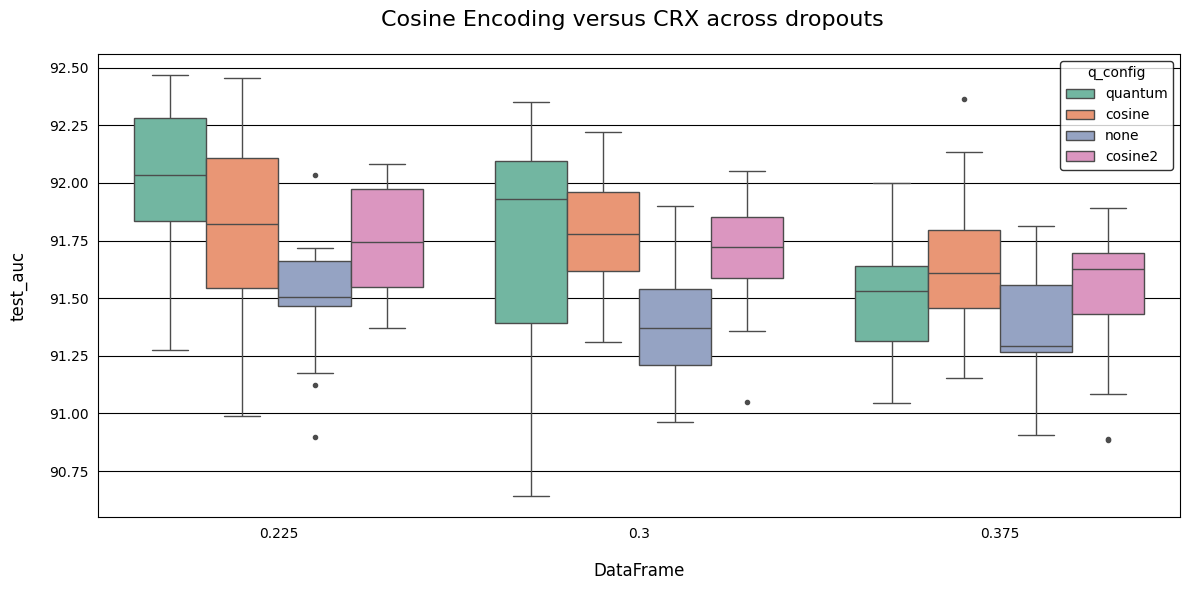

In [10]:
plot_boxplots([df], [""], split = "dropout", separation = "q_config", TEXT_COLOR='black', BACKGROUND_COLOR='#ffffff00', BOX_COLOR='#4c4c4cff', title = "Cosine Encoding versus CRX across dropouts")


Background_color: #ffffff00


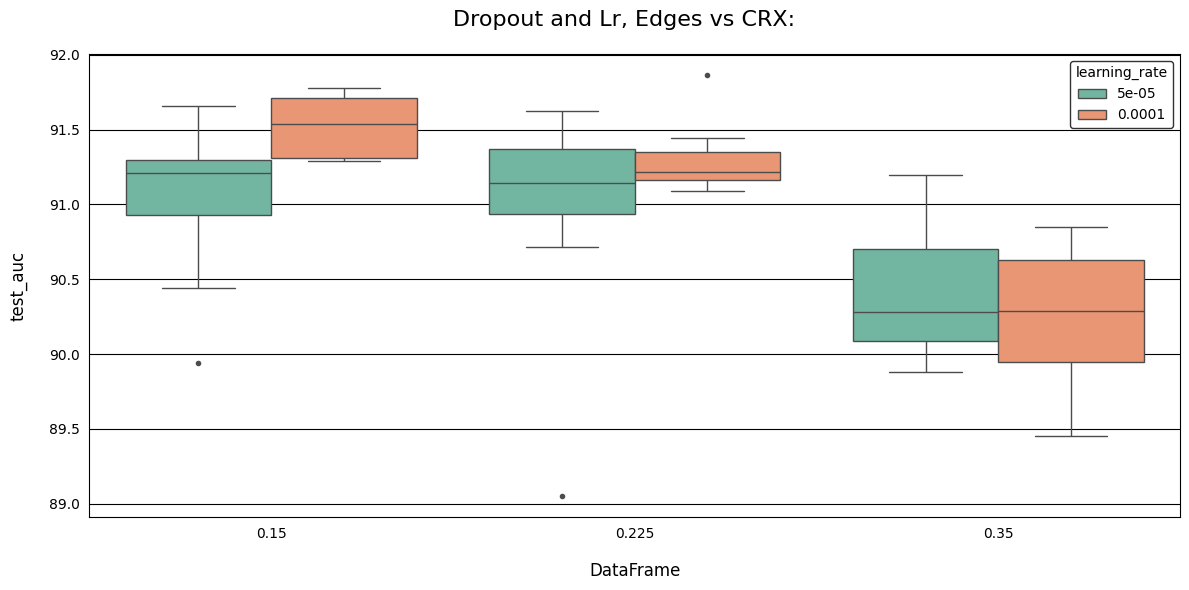

Background_color: #ffffff00


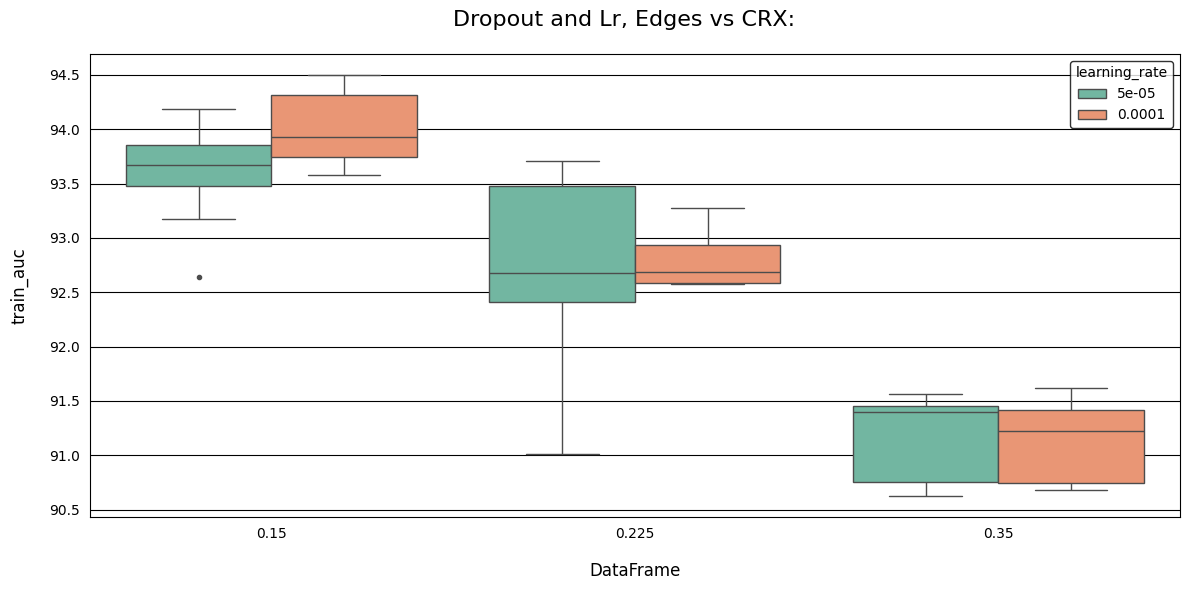

In [11]:
def df_list_f(df, split_by):
    
    df_list = []
    labels = []
    for element in list(df[split_by].unique()):
        df_list.append( df[ df[split_by] == element ] )
        labels.append(str(element))
    
    return df_list, labels

path = "first_search_for_224/results_grid_search.csv"
df = pd.read_csv(path)

df_list, labels = df_list_f(df, split_by= "dropout")

plot_boxplots([df], [""], split = "dropout", separation = "learning_rate", TEXT_COLOR='black', BACKGROUND_COLOR='#ffffff00', BOX_COLOR='#4c4c4cff', title = "Dropout and Lr, Edges vs CRX: ")
plot_boxplots([df], [""], split = "dropout", separation = "learning_rate", value_column='train_auc', TEXT_COLOR='black', BACKGROUND_COLOR='#ffffff00', BOX_COLOR='#4c4c4cff', title = "Dropout and Lr, Edges vs CRX: ")

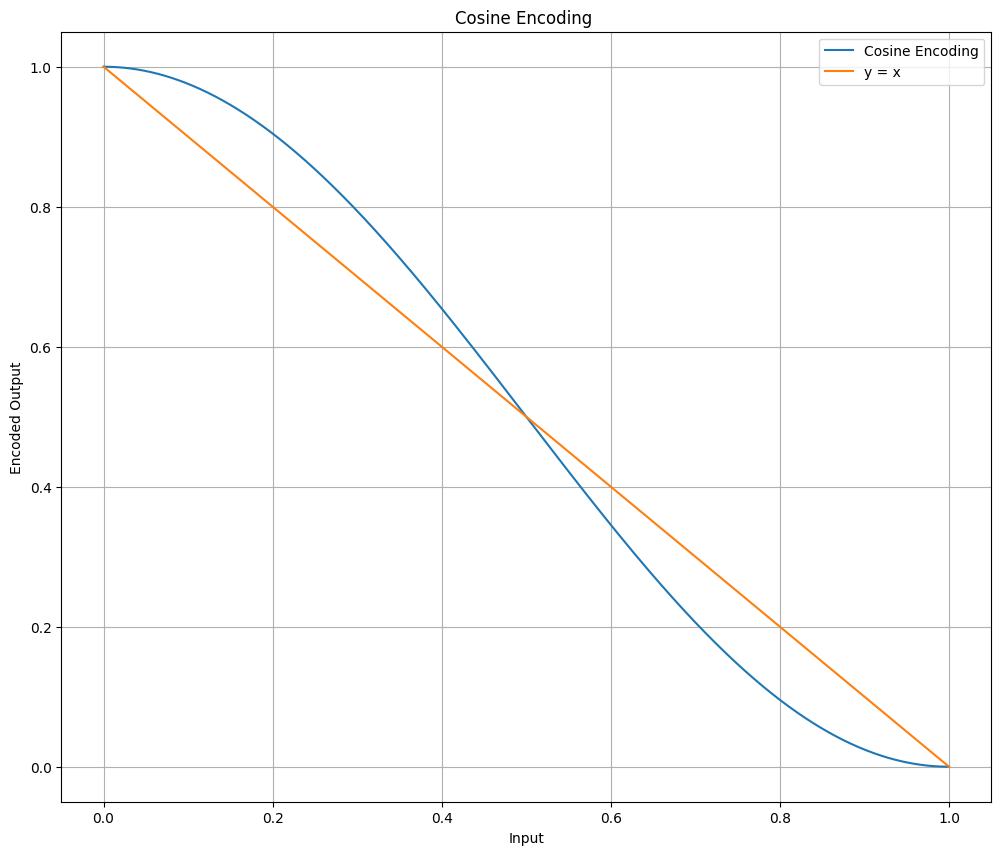

In [2]:
import numpy as np
import torch 
import matplotlib.pyplot as plt

x = torch.linspace(0, 1, 1000)

class CosineEncoding(torch.nn.Module):
    def __init__(self, nesting = 1):
        super(CosineEncoding, self).__init__()
        self.nesting = nesting
    def forward(self, x):
        out = x
        for _ in range(self.nesting):
            out = torch.cos( (1-out) * torch.pi/2 )
        return out**2

cosine = CosineEncoding(nesting = 1)

y1 = (torch.cos((x)*torch.pi/2)**2).detach().numpy()
y2 = 1-x.detach().numpy()

plt.figure(figsize=(12, 10))

plt.plot(x.detach().numpy(), y1, label='Cosine Encoding')
plt.plot(x.detach().numpy(), y2, label='y = x')
plt.title('Cosine Encoding ')
plt.xlabel('Input')
plt.ylabel('Encoded Output')
plt.legend()
plt.grid()
plt.show()

# Resolutions:

# 28 x 28

Background_color: #1F1F1F


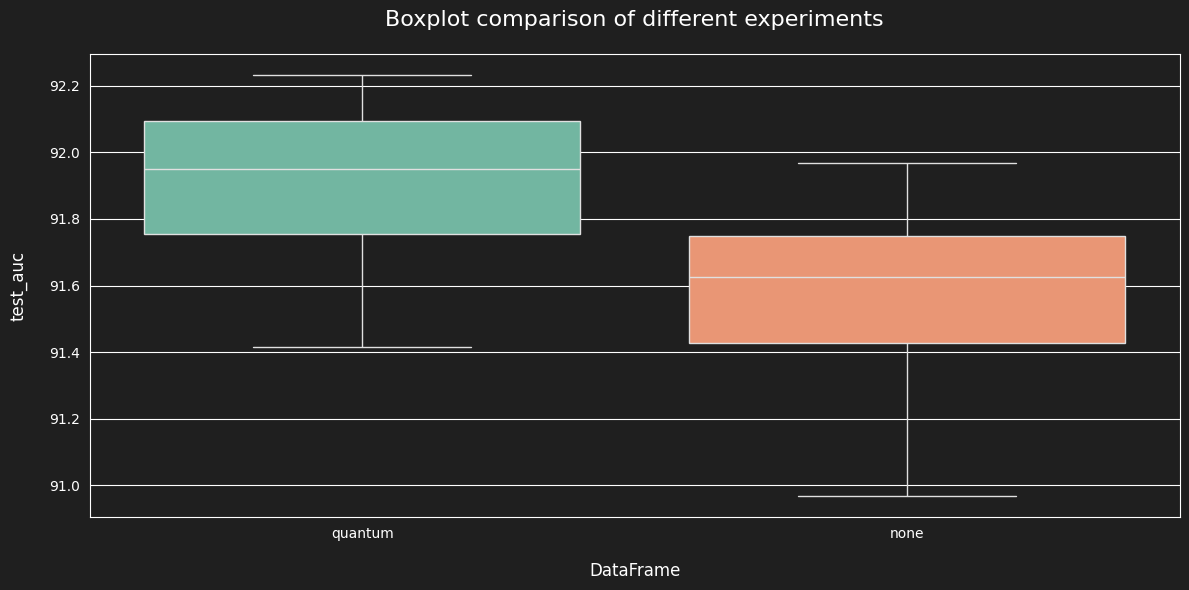

In [14]:
path = "28x28/redo_quantum_vs_none_crx/results_grid_search.csv"
df = pd.read_csv(path)
df_list, labels = df_list_f(df, split_by= "q_config")
plot_boxplots(df_list, labels)

# 64 x 64

Background_color: #1F1F1F


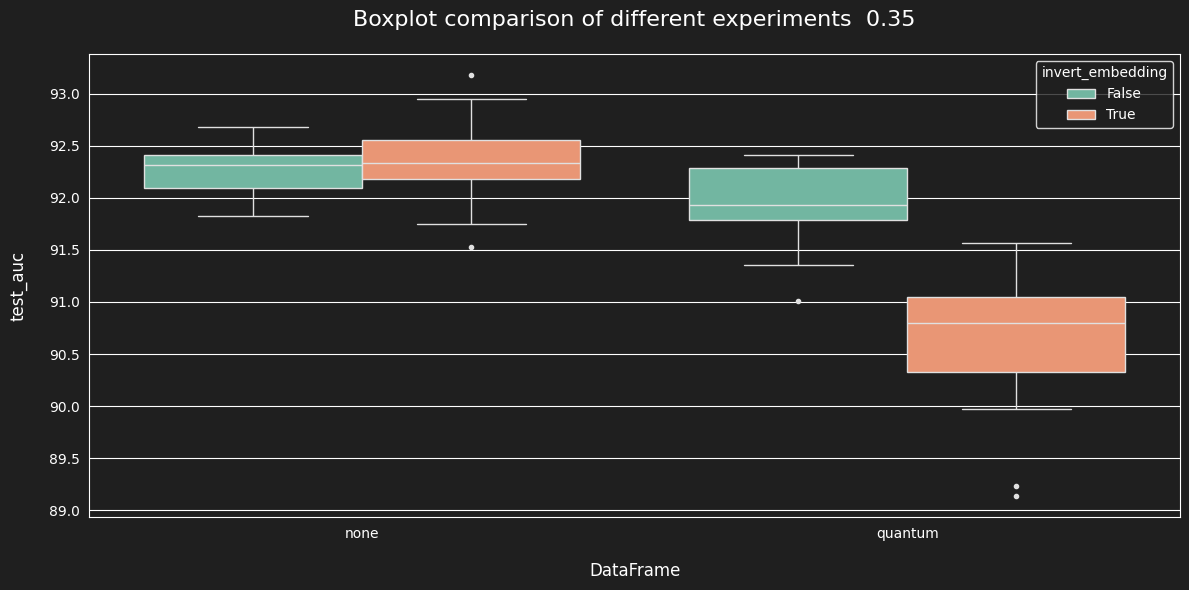

Background_color: #1F1F1F


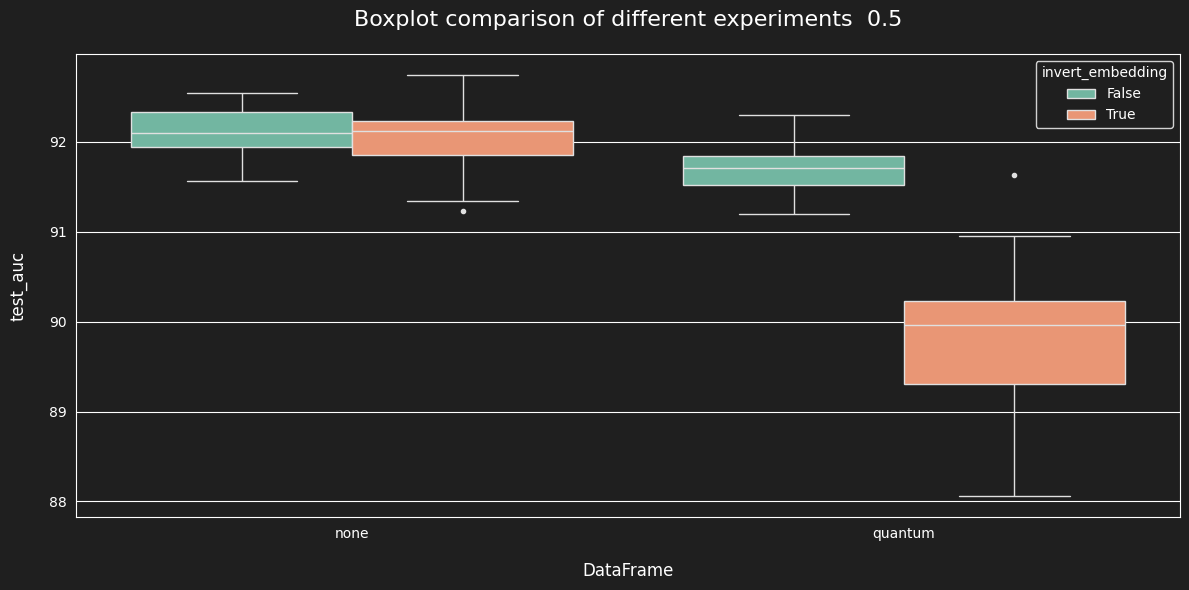

In [22]:
path = "64x64/CRX_v_Edges_invert_q_v_c_dropout/results_grid_search.csv"
df = pd.read_csv(path)
# Robustly filter out rows where channels_out indicates a single channel [1]
def _channels_out_is_single_one(x):
    try:
        if isinstance(x, (list, tuple)):
            return x == [1] or 1 in x
        return x == 1 or str(x) == '[1]'
    except Exception:
        return False
    
mask = df['channels_out'].apply(_channels_out_is_single_one)
df = df[~mask].reset_index(drop=True)
df_list, labels = df_list_f(df, split_by= "dropout")
plot_boxplots(df_list, labels, separation= "invert_embedding", split = "q_config")

# 128 x 128

Background_color: #1F1F1F


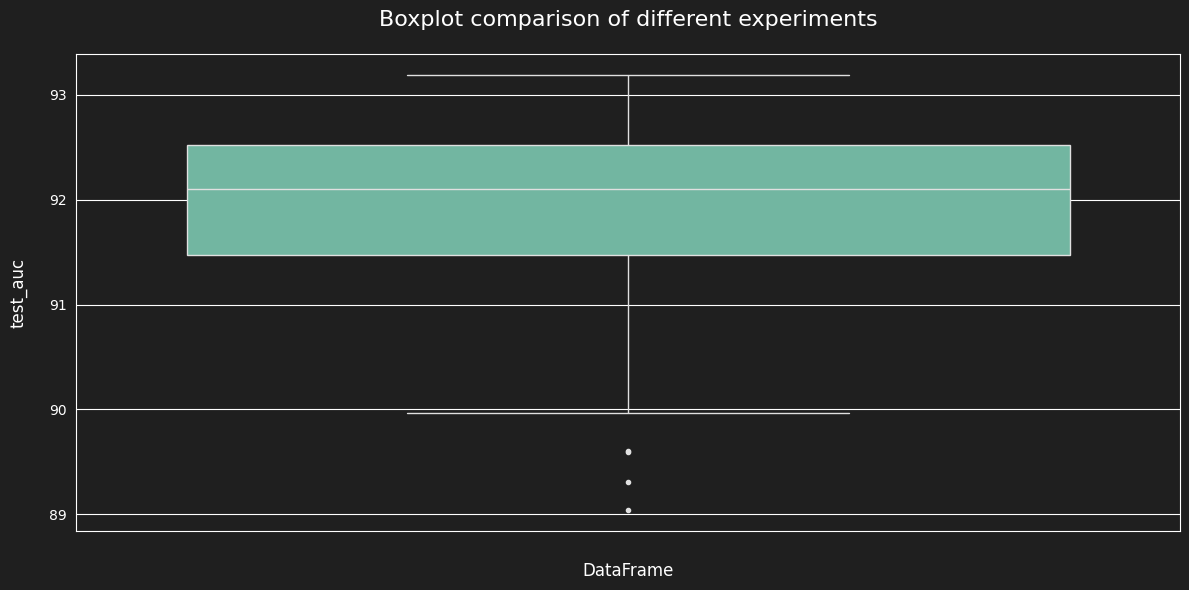

In [23]:
path = "128x128/first_search_for_128/results_grid_search.csv"
df = pd.read_csv(path)
plot_boxplots([df], [""])

Background_color: #1F1F1F


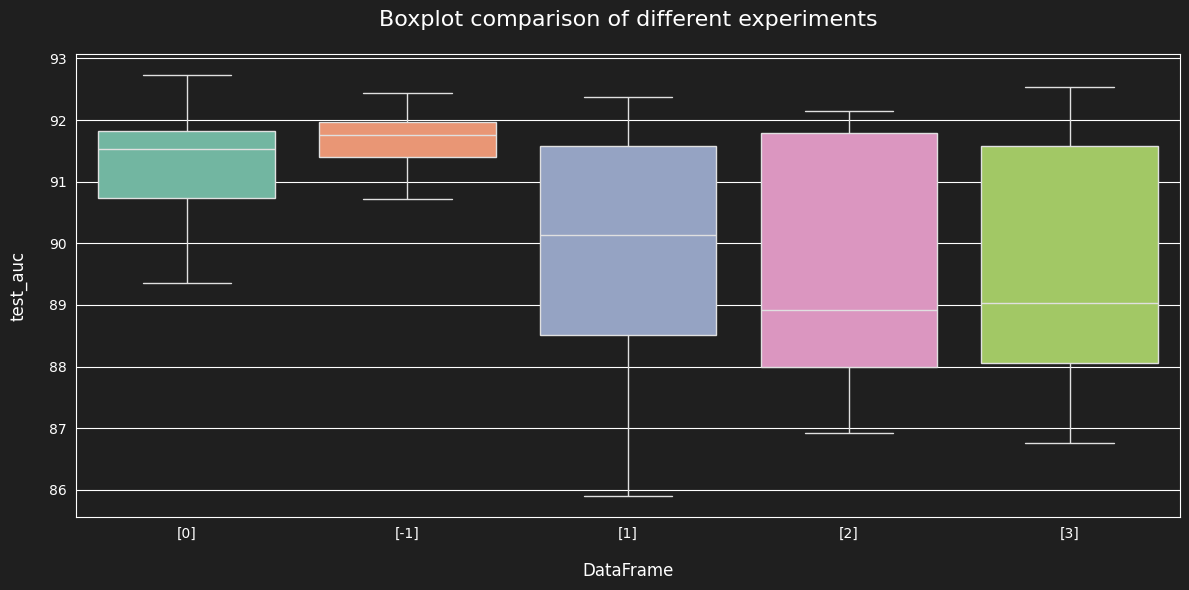

In [24]:
path = "128x128/quantum_vs_none/results_grid_search.csv"
df = pd.read_csv(path)
df_list, labels = df_list_f(df, split_by= "channel")
plot_boxplots(df_list, labels)

# 224 x 224

Background_color: #1F1F1F


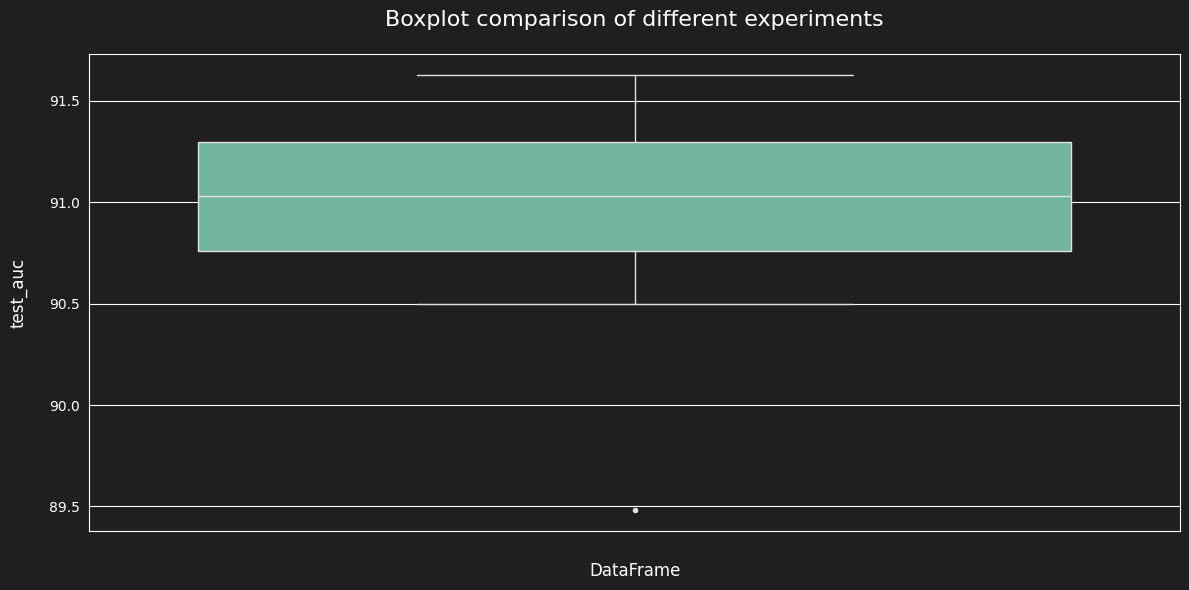

In [25]:
path = "224x224/second_search_for_224/results_grid_search.csv"
df = pd.read_csv(path)
plot_boxplots([df], [""])

# Experiments for Thesis (FROM HERE BELOW)

# 1 First grid search 1 Transformer

In [1]:
import pandas as pd
from benri.data import aggregate_and_save_top_configs
df = pd.read_csv("ExperimentsForThesis/28x28/first_fine_tuning_1_transf/results_grid_search.csv").reset_index()

graph_columns = ['learning_rate', 'dropout', 'mlp_size', 'num_head', 'test_auc']
value_column = graph_columns[-1]
group_cols = graph_columns[:-1]
agg, top = aggregate_and_save_top_configs(df, group_cols, value_column, "ExperimentsForThesis/28x28/first_fine_tuning_1_transf/aggregated_tables", n=10)

Saved aggregated results to ExperimentsForThesis/28x28/first_fine_tuning_1_transf/aggregated_tables/aggregated_test_auc.csv
Saved top 10 configurations to ExperimentsForThesis/28x28/first_fine_tuning_1_transf/aggregated_tables/top_10_test_auc.csv
 learning_rate  dropout  mlp_size  num_head    median      std
        0.0025    0.175         9        48 91.819603 0.118316
        0.0075    0.225         7        48 91.789133 0.144723
        0.0025    0.175         5        48 91.752900 0.153302
        0.0025    0.175         7        48 91.738121 0.224075
        0.0075    0.175         7        48 91.717720 0.252242
        0.0025    0.225         5        48 91.675003 0.153003
        0.0025    0.225         3        48 91.660107 0.176673
        0.0075    0.225         9        48 91.659557 0.158121
        0.0075    0.275         9        48 91.649662 0.228032
        0.0025    0.175         3        48 91.645612 0.186033


# First Grid Search 2 Transformers

In [2]:
import pandas as pd
from benri.data import aggregate_and_save_top_configs
df = pd.read_csv("ExperimentsForThesis/28x28/first_fine_tuning_2_transf/results_grid_search.csv").reset_index()

graph_columns = ['learning_rate', 'dropout', 'mlp_size', 'num_head', 'test_auc']
value_column = graph_columns[-1]    
group_cols = graph_columns[:-1]
agg, top = aggregate_and_save_top_configs(df, group_cols, value_column, "ExperimentsForThesis/28x28/first_fine_tuning_2_transf/aggregated_tables", n=10)

Saved aggregated results to ExperimentsForThesis/28x28/first_fine_tuning_2_transf/aggregated_tables/aggregated_test_auc.csv
Saved top 10 configurations to ExperimentsForThesis/28x28/first_fine_tuning_2_transf/aggregated_tables/top_10_test_auc.csv
 learning_rate  dropout  mlp_size  num_head    median      std
        0.0025    0.175         9        48 91.925942 0.215025
        0.0025    0.225         5        16 91.918558 0.216052
        0.0075    0.275         5        16 91.863636 0.281696
        0.0025    0.175         5        16 91.861680 0.284280
        0.0025    0.175         7        48 91.858556 0.223772
        0.0025    0.175         3        16 91.851654 0.277277
        0.0075    0.225         7         8 91.846903 0.354385
        0.0075    0.225         7        16 91.829402 0.258279
        0.0025    0.275         7        16 91.823132 0.256789
        0.0075    0.225         5        16 91.815601 0.274168


# Filter

In [3]:
import pandas as pd
from benri.data import aggregate_and_save_top_configs
df = pd.read_csv("ExperimentsForThesis/28x28/filter/results_grid_search.csv").reset_index()

graph_columns = ['selection_amount', 'test_auc']
value_column = graph_columns[-1]    
group_cols = graph_columns[:-1]
agg, top = aggregate_and_save_top_configs(df, group_cols, value_column, "ExperimentsForThesis/28x28/filter/aggregated_tables", n=6)

Saved aggregated results to ExperimentsForThesis/28x28/filter/aggregated_tables/aggregated_test_auc.csv
Saved top 6 configurations to ExperimentsForThesis/28x28/filter/aggregated_tables/top_6_test_auc.csv
 selection_amount    median      std
               20 92.209816 0.280684
               30 92.107256 0.266212
               40 92.067272 0.267277
               25 92.039005 0.248521
               15 91.999374 0.266102
               49 91.918489 0.379945


# Q Stride

In [4]:
import pandas as pd
from benri.data import aggregate_and_save_top_configs
df = pd.read_csv("ExperimentsForThesis/28x28/q_stride/results_grid_search.csv").reset_index()

graph_columns = ['q_stride', 'test_auc']
value_column = graph_columns[-1]    
group_cols = graph_columns[:-1]
agg, top = aggregate_and_save_top_configs(df, group_cols, value_column, "ExperimentsForThesis/28x28/q_stride/aggregated_tables", n=4)

Saved aggregated results to ExperimentsForThesis/28x28/q_stride/aggregated_tables/aggregated_test_auc.csv
Saved top 4 configurations to ExperimentsForThesis/28x28/q_stride/aggregated_tables/top_4_test_auc.csv
 q_stride    median      std
        8 91.940329 0.255006
        4 91.898471 0.326056
        2 91.882842 0.288083
        1 91.681807 0.294761


# Parallel

In [5]:
import pandas as pd
from benri.data import aggregate_and_save_top_configs
df = pd.read_csv("ExperimentsForThesis/28x28/parallel/results_grid_search.csv").reset_index()

graph_columns = ['parallel', 'test_auc']
value_column = graph_columns[-1]    
group_cols = graph_columns[:-1]
agg, top = aggregate_and_save_top_configs(df, group_cols, value_column, "ExperimentsForThesis/28x28/parallel/aggregated_tables", n=4)

Saved aggregated results to ExperimentsForThesis/28x28/parallel/aggregated_tables/aggregated_test_auc.csv
Saved top 4 configurations to ExperimentsForThesis/28x28/parallel/aggregated_tables/top_4_test_auc.csv
 parallel    median      std
        2 91.943034 0.326935
        3 91.730623 0.374255
        4 91.593780 0.264011
        1 91.257447 0.211071


# First Quantum (CNOTS)
With 2 transformers

In [4]:
import pandas as pd
from benri.data import aggregate_and_save_top_configs
df = pd.read_csv("ExperimentsForThesis/28x28/first_quantum/results_grid_search.csv").reset_index()

graph_columns = ['quantum', 'invert_embedding', 'test_auc']
value_column = graph_columns[-1]    
group_cols = graph_columns[:-1]
agg, top = aggregate_and_save_top_configs(df, group_cols, value_column, "ExperimentsForThesis/28x28/first_quantum/aggregated_tables", n=5)

Saved aggregated results to ExperimentsForThesis/28x28/first_quantum/aggregated_tables/aggregated_test_auc.csv
Saved top 5 configurations to ExperimentsForThesis/28x28/first_quantum/aggregated_tables/top_5_test_auc.csv
 quantum  invert_embedding    median      std
   False             False 91.797394 0.312888
    True             False 91.741020 0.221338
    True              True 91.722112 0.307579
   False              True 91.714765 0.252344


# Quantum but with CRX

In [3]:
import pandas as pd
from benri.data import aggregate_and_save_top_configs
df = pd.read_csv("ExperimentsForThesis/28x28/quantum_crx/results_grid_search.csv").reset_index()

graph_columns = ['quantum', 'invert_embedding', 'test_auc']
value_column = graph_columns[-1]  

group_cols = graph_columns[:-1]
agg, top = aggregate_and_save_top_configs(df, group_cols, 'test_auc', "ExperimentsForThesis/28x28/quantum_crx/aggregated_tables", n=5)

Saved aggregated results to ExperimentsForThesis/28x28/quantum_crx/aggregated_tables/aggregated_test_auc.csv
Saved top 5 configurations to ExperimentsForThesis/28x28/quantum_crx/aggregated_tables/top_5_test_auc.csv
 quantum  invert_embedding    median      std
   False              True 91.760934 0.279142
   False             False 91.737931 0.330283
    True             False 91.730187 0.275515
    True              True 91.716736 0.283018


# Quantum with unitary 3 trainable (CRX)

In [2]:
import pandas as pd
from benri.data import aggregate_and_save_top_configs
df = pd.read_csv("ExperimentsForThesis/28x28/quantum_training/results_grid_search.csv").reset_index()

graph_columns = ['quantum', 'train_q', 'test_auc']
value_column = graph_columns[-1]  

group_cols = graph_columns[:-1]
agg, top = aggregate_and_save_top_configs(df, group_cols, 'test_auc', "ExperimentsForThesis/28x28/quantum_training/aggregated_tables", n=5)

Saved aggregated results to ExperimentsForThesis/28x28/quantum_training/aggregated_tables/aggregated_test_auc.csv
Saved top 5 configurations to ExperimentsForThesis/28x28/quantum_training/aggregated_tables/top_5_test_auc.csv
 quantum  train_q    median      std
   False    False 91.882309 0.301836
    True     True 91.857264 0.268876
   False     True 91.828573 0.285918
    True    False 91.810937 0.294965


# Quantum with unitary 3 trainable and CRX trainable

AUC results:
Saved aggregated results to ExperimentsForThesis/28x28/quantum_training_crx_training/aggregated_tables/aggregated_test_auc.csv
Saved top 6 configurations to ExperimentsForThesis/28x28/quantum_training_crx_training/aggregated_tables/top_6_test_auc.csv
 quantum  U3_layers  entangling_layers    median      std
    True       True               True 91.819576 0.284855
    True       True              False 91.762822 0.311373
    True      False              False 91.755460 0.294567
   False      False              False 91.705830 0.283346
    True      False               True 91.697660 0.265977
Background_color: #ffffff00


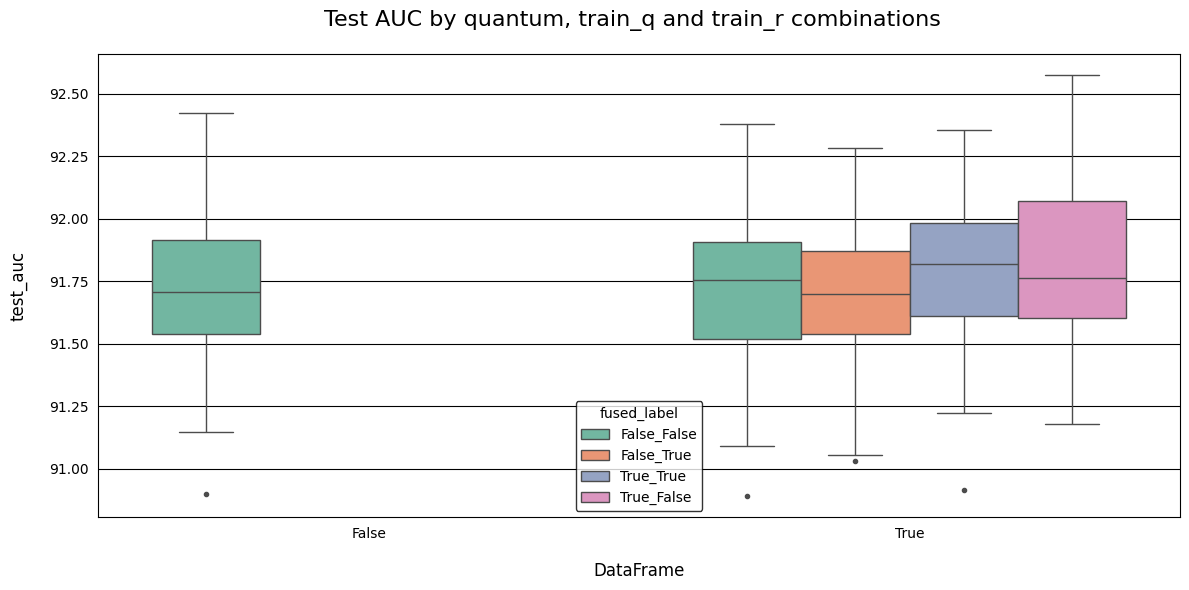

ACC results:
Saved aggregated results to ExperimentsForThesis/28x28/quantum_training_crx_training/aggregated_tables/aggregated_test_acc.csv
Saved top 6 configurations to ExperimentsForThesis/28x28/quantum_training_crx_training/aggregated_tables/top_6_test_acc.csv
 quantum  U3_layers  entangling_layers    median      std
    True       True              False 74.688279 0.970518
   False      False              False 74.663342 0.967948
    True       True               True 74.588529 0.929731
    True      False              False 74.463840 1.099665
    True      False               True 74.389027 0.859973
Background_color: #ffffff00


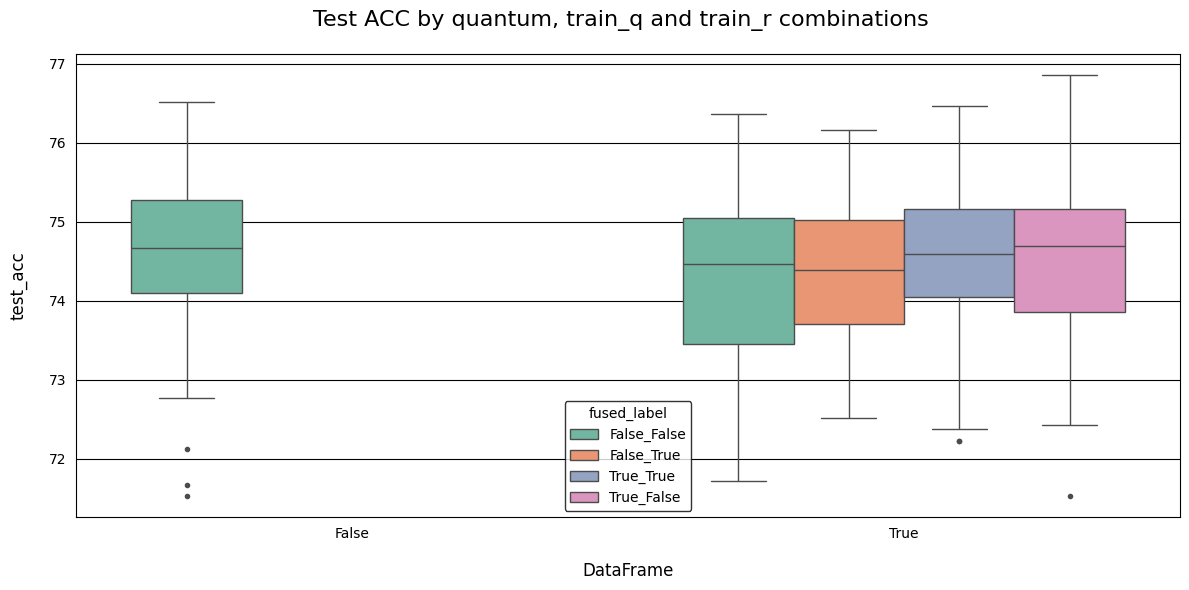

In [8]:
import pandas as pd
from benri.data import aggregate_and_save_top_configs
df = pd.read_csv("ExperimentsForThesis/28x28/quantum_training_crx_training/results_grid_search.csv").reset_index()

graph_columns = ['quantum', 'U3_layers','entangling_layers', 'test_auc']
value_column = graph_columns[-1]  

print("AUC results:")
group_cols = graph_columns[:-1]
agg, top = aggregate_and_save_top_configs(df, group_cols, 'test_auc', "ExperimentsForThesis/28x28/quantum_training_crx_training/aggregated_tables", n=6)

df['fused_label'] =  df['U3_layers'].astype(str) + "_" + df['entangling_layers'].astype(str)
plot_boxplots([df], [""], split = 'quantum', separation = 'fused_label', TEXT_COLOR='black', BACKGROUND_COLOR='#ffffff00', BOX_COLOR='#4c4c4cff', title = "Test AUC by quantum, train_q and train_r combinations",)
print("ACC results:")
aggacc, topacc = aggregate_and_save_top_configs(df, group_cols, 'test_acc', "ExperimentsForThesis/28x28/quantum_training_crx_training/aggregated_tables", n=6)

plot_boxplots([df], [""], split = 'quantum', separation = 'fused_label', value_column='test_acc', TEXT_COLOR='black', BACKGROUND_COLOR='#ffffff00', BOX_COLOR='#4c4c4cff', title = "Test ACC by quantum, train_q and train_r combinations",)

# Quantum training CRX training higher MLP

In [3]:
import pandas as pd
from benri.data import aggregate_and_save_top_configs
df = pd.read_csv("ExperimentsForThesis/28x28/quantum_training_crx_training_higher_mlp/results_grid_search.csv").reset_index()

graph_columns = ['quantum', 'U3_layers', 'entangling_layers', 'test_auc']
value_column = graph_columns[-1]  

print("AUC results:")
group_cols = graph_columns[:-1]
agg, top = aggregate_and_save_top_configs(df, group_cols, 'test_auc', "ExperimentsForThesis/28x28/quantum_training_crx_training_higher_mlp/aggregated_tables", n=5)

print("ACC results:")
group_cols = graph_columns[:-1]
agg, top = aggregate_and_save_top_configs(df, group_cols, 'test_acc', "ExperimentsForThesis/28x28/quantum_training_crx_training_higher_mlp/aggregated_tables", n=5)

AUC results:
Saved aggregated results to ExperimentsForThesis/28x28/quantum_training_crx_training_higher_mlp/aggregated_tables/aggregated_test_auc.csv
Saved top 5 configurations to ExperimentsForThesis/28x28/quantum_training_crx_training_higher_mlp/aggregated_tables/top_5_test_auc.csv
 quantum  U3_layers  entangling_layers    median      std
   False      False              False 92.040494 0.245867
    True      False               True 92.017213 0.302617
    True       True              False 92.002157 0.233727
    True       True               True 91.931243 0.225800
    True      False              False 91.889649 0.246308
ACC results:
Saved aggregated results to ExperimentsForThesis/28x28/quantum_training_crx_training_higher_mlp/aggregated_tables/aggregated_test_acc.csv
Saved top 5 configurations to ExperimentsForThesis/28x28/quantum_training_crx_training_higher_mlp/aggregated_tables/top_5_test_acc.csv
 quantum  U3_layers  entangling_layers    median      std
   False      False   

# Higher MLP = 5 plus training

In [2]:
import pandas as pd
from benri.data import aggregate_and_save_top_configs
df = pd.read_csv("ExperimentsForThesis/28x28/quantum_training_crx_training_higher_mlp_more_qvc/results_grid_search.csv").reset_index()

graph_columns = ['quantum', 'U3_layers', 'entangling_layers', 'test_auc']
value_column = graph_columns[-1]  

print("AUC results:")
group_cols = graph_columns[:-1]
agg, top = aggregate_and_save_top_configs(df, group_cols, 'test_auc', "ExperimentsForThesis/28x28/quantum_training_crx_training_higher_mlp_more_qvc/aggregated_tables", n=5)

print("ACC results:")
group_cols = graph_columns[:-1]
agg, top = aggregate_and_save_top_configs(df, group_cols, 'test_acc', "ExperimentsForThesis/28x28/quantum_training_crx_training_higher_mlp_more_qvc/aggregated_tables", n=5)

AUC results:
Saved aggregated results to ExperimentsForThesis/28x28/quantum_training_crx_training_higher_mlp_more_qvc/aggregated_tables/aggregated_test_auc.csv
Saved top 5 configurations to ExperimentsForThesis/28x28/quantum_training_crx_training_higher_mlp_more_qvc/aggregated_tables/top_5_test_auc.csv
 quantum  U3_layers  entangling_layers    median      std
    True          2                  2 91.858146 0.199114
    True          0                  2 91.821379 0.251895
   False          0                  0 91.800204 0.235817
    True          0                  0 91.750880 0.283826
    True          2                  0 91.740183 0.227895
ACC results:
Saved aggregated results to ExperimentsForThesis/28x28/quantum_training_crx_training_higher_mlp_more_qvc/aggregated_tables/aggregated_test_acc.csv
Saved top 5 configurations to ExperimentsForThesis/28x28/quantum_training_crx_training_higher_mlp_more_qvc/aggregated_tables/top_5_test_acc.csv
 quantum  U3_layers  entangling_layers    me

# Higher MLP + Filter synergy

In [1]:
import pandas as pd
from benri.data import aggregate_and_save_top_configs
from benri.graphics import plot_boxplots
df = pd.read_csv("ExperimentsForThesis/28x28/q_train_crx_train_high_mlp_filter_synergy/results_grid_search.csv").reset_index()

graph_columns = ['selection_amount', 'quantum', 'U3_layers', 'entangling_layers', 'test_auc']
value_column = graph_columns[-1]  

print("AUC results:")
group_cols = graph_columns[:-1]
agg, top = aggregate_and_save_top_configs(df, group_cols, 'test_auc', "ExperimentsForThesis/28x28/q_train_crx_train_high_mlp_filter_synergy/aggregated_tables", n=10)

print("ACC results:")
group_cols = graph_columns[:-1]
agg, top = aggregate_and_save_top_configs(df, group_cols, 'test_acc', "ExperimentsForThesis/28x28/q_train_crx_train_high_mlp_filter_synergy/aggregated_tables", n=10)


AUC results:
Saved aggregated results to ExperimentsForThesis/28x28/q_train_crx_train_high_mlp_filter_synergy/aggregated_tables/aggregated_test_auc.csv
Saved top 10 configurations to ExperimentsForThesis/28x28/q_train_crx_train_high_mlp_filter_synergy/aggregated_tables/top_10_test_auc.csv
 selection_amount  quantum  U3_layers  entangling_layers    median      std
               30    False          0                  0 92.012349 0.237751
               20    False          0                  0 92.010898 0.229268
               30     True          1                  2 91.982081 0.239595
               49     True          2                  1 91.973589 0.203707
               30     True          2                  1 91.971330 0.285450
               20     True          1                  2 91.956518 0.256159
               30     True          2                  2 91.954417 0.267696
               20     True          2                  2 91.950047 0.256026
               30     True

# Quantum Synergy with Q_Stride but again low QVC (3)

In [2]:
import pandas as pd
from benri.data import aggregate_and_save_top_configs
from benri.graphics import plot_boxplots
df = pd.read_csv("ExperimentsForThesis/28x28/quantum_training_crx_training_q_stride/results_grid_search.csv").reset_index()

graph_columns = ['q_stride', 'quantum', 'U3_layers', 'entangling_layers', 'test_auc']
value_column = graph_columns[-1]  

print("AUC results:")
group_cols = graph_columns[:-1]
agg, top = aggregate_and_save_top_configs(df, group_cols, 'test_auc', "ExperimentsForThesis/28x28/quantum_training_crx_training_q_stride/aggregated_tables", n=10)

print("ACC results:")
group_cols = graph_columns[:-1]
agg, top = aggregate_and_save_top_configs(df, group_cols, 'test_acc', "ExperimentsForThesis/28x28/quantum_training_crx_training_q_stride/aggregated_tables", n=10)


AUC results:
Saved aggregated results to ExperimentsForThesis/28x28/quantum_training_crx_training_q_stride/aggregated_tables/aggregated_test_auc.csv
Saved top 10 configurations to ExperimentsForThesis/28x28/quantum_training_crx_training_q_stride/aggregated_tables/top_10_test_auc.csv
 q_stride  quantum  U3_layers  entangling_layers    median      std
        4     True          2                  2 92.001809 0.245130
        1     True          0                  2 91.928879 0.326051
        4     True          1                  1 91.928594 0.326408
        2     True          1                  0 91.914414 0.301468
        2     True          2                  2 91.907375 0.359733
        2     True          1                  1 91.907337 0.211898
        4     True          1                  2 91.906545 0.300660
        2    False          0                  0 91.905082 0.363985
        3     True          2                  2 91.897811 0.283849
        2     True          2       

In [6]:
import pandas as pd
from benri.data import aggregate_and_save_top_configs
from benri.graphics import plot_boxplots
df = pd.read_csv("ExperimentsForThesis/28x28/q_preprocessor/results_grid_search.csv").reset_index()

graph_columns = ['preprocessor', 'test_auc']
value_column = graph_columns[-1]  

print("AUC results:")
group_cols = graph_columns[:-1]
agg, top = aggregate_and_save_top_configs(df, group_cols, 'val_auc', "ExperimentsForThesis/28x28/q_preprocessor/aggregated_tables", n=10)

print("ACC results:")
group_cols = graph_columns[:-1]
agg, top = aggregate_and_save_top_configs(df, group_cols, 'val_acc', "ExperimentsForThesis/28x28/q_preprocessor/aggregated_tables", n=10)


AUC results:
Saved aggregated results to ExperimentsForThesis/28x28/q_preprocessor/aggregated_tables/aggregated_val_auc.csv
Saved top 10 configurations to ExperimentsForThesis/28x28/q_preprocessor/aggregated_tables/top_10_val_auc.csv
preprocessor    median      std
   classical 92.442364 0.365275
        none 92.254079 0.198231
     quantum 92.145427 0.905060
ACC results:
Saved aggregated results to ExperimentsForThesis/28x28/q_preprocessor/aggregated_tables/aggregated_val_acc.csv
Saved top 10 configurations to ExperimentsForThesis/28x28/q_preprocessor/aggregated_tables/top_10_val_acc.csv
preprocessor    median      std
   classical 74.077767 0.956557
        none 74.077767 1.091438
     quantum 73.080758 1.882619
